In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch as t
import tqdm.auto as tqdm_auto
from tqdm.std import tqdm as std_tqdm

tqdm_auto.tqdm = std_tqdm

from forget.model.base import AutoModelForCausalLMWrapper

from intervention import (
    RunSpec,
    run_intervention_generations,
    sample_per_concept,
)
from activations import (
    collect_concept_activations,
    pool_activation_dict,
)
from steering import lda_vectors

In [46]:
sns.set_theme(context='talk', style='ticks', palette='dark')
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'
plt.rcParams["savefig.transparent"] = True  # Ensures saved figures are transparent
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['figure.figsize'] = [3.0,3.0]
plt.rcParams['patch.linewidth'] = 0

import matplotlib as mpl
from matplotlib import rcParams
from matplotlib.colors import ListedColormap

rcParams['image.interpolation'] = 'none'

plt.rcParams.update({
    "legend.frameon": False,   # remove border/frame
    "legend.loc": "lower right", # default legend position
})

colors = mpl.colormaps['RdYlBu_r'](np.linspace(0, 1, 10))
CUSTOM_CMAP = ListedColormap(colors)

In [4]:

# sns.despine(trim=True, ax=ax)
# ax.legend(labelcolor='linecolor', handlelength=0, loc=(1.0, 0.5))


# plt.figure(dpi=150)
# sns.lineplot(data=inter_dgd_df, x="layer", y="inter_dgd", color="darkred")
# plt.ylabel("DGD")
# plt.xlabel(r"Layer $\ell$")
# plt.xticks([0, 32])
# plt.yticks([0, 1])
# sns.despine(trim=True, offset=4)
# plt.show()

# Files

In [5]:
# Artifact store
STORE = Path("store/llama3_concepts")
STORE.mkdir(parents=True, exist_ok=True)

# Datasets
DATA_STORE = Path("store/concepts")
TRAIN_PATH = DATA_STORE / "train.csv"
TEST_PATH = DATA_STORE / "test.csv"

# Baseline Generations
BASELINE_TRAIN_PATH = STORE / "baseline_train.csv"
BASELINE_TEST_PATH = STORE / "baseline_test.csv"

# Train Activations
BASELINE_ACTS_PATH = STORE / "baseline_answer_acts.pt"
BASELINE_MASKS_PATH = STORE / "baseline_answer_masks.pt"
REFUSE_ACTS_PATH = STORE / "refuse_answer_acts.pt"
REFUSE_MASKS_PATH = STORE / "refuse_answer_masks.pt"

# Train Vectors and Thresholds
V_DETECT_PATH = STORE / "v_detect.pt"
V_REFUSE_PER_PATH = STORE / "v_refuse_per.pt"
V_REFUSE_PATH = STORE / "v_refuse.pt"
THRESHOLDS_PATH = STORE / "thresholds.pt"

# Test Activations
BASELINE_TEST_ACTS_PATH = STORE / "baseline_answer_acts_test.pt"
BASELINE_TEST_MASKS_PATH = STORE / "baseline_answer_masks_test.pt"

# Results and Scoring
RESULTS_PATH = STORE / "results.csv"
SCORED_PATH = STORE / "scored.csv"

# Notaton

In [6]:
NOTATIONS = {
    "c": r"$c$",
    "c_prime": r"$c'$",
    "layer": r"$\ell$",
    "t": r"$t$",
    "D": r"$\mathcal{D}$",
    "D_pos": r"$\mathcal{D}^{+}_{c}$",
    "D_neg": r"$\mathcal{D}^{-}_{c}$",
    "h": r"$h^{(\ell)}_t$",
    "d": r"$d^{(\ell)}_{c}$",
    "tau": r"$\tau^{(\ell)}_{c}$",
    "r": r"$r^{(\ell)}$",
    "s": r"$s$",
}

PRIMARY_COLOR = "darkred"
SECONDARY_COLOR = "black"

# Model Setup

In [7]:
# Chat formatting tags
B_SYS = "<|start_header_id|>system<|end_header_id|>\n\n"
E_SYS = "<|eot_id|>"
B_USER = "<|start_header_id|>user<|end_header_id|>\n\n"
E_USER = "<|eot_id|>"
B_ASSISTANT = "<|start_header_id|>assistant<|end_header_id|>\n\n"
E_ASSISTANT = "<|eot_id|>"

# Position markers for activation steering
# Steer from the assistant header onwards
ADD_FROM_POS_CHAT = B_ASSISTANT

# End of prompt sequence token tensor
END_STR = None

# Special tokens
BOS = "<|begin_of_text|>"
EOS = "<|eot_id|>"

In [8]:
HF_TOKEN = os.getenv("HF_TOKEN")
model_path = "meta-llama/Llama-3.1-8B-Instruct"
llm = AutoModelForCausalLMWrapper(
    hf_token=HF_TOKEN,
    model_path=model_path,
    instruction_end_marker=ADD_FROM_POS_CHAT,
    tokenizer_path=model_path,
    gpu_id=0,
    )

Loading weights: 100%|██████████| 291/291 [00:00<00:00, 13969.33it/s]


In [9]:
prompt = f"{BOS}{B_SYS}You are a helpful assistant.{E_SYS}{B_USER}What is the capital of France?{E_USER}{B_ASSISTANT}"
generated = llm.batch_generate([prompt], max_new_tokens=64, do_sample=False, temperature=1.0)[0]
generated.split(B_ASSISTANT, maxsplit=1)[-1]

'The capital of France is Paris.<|eot_id|>'

# Dataset

In [10]:
def melt_layers(values, value_name):
    return pd.DataFrame(values).rename_axis("sample").reset_index().melt("sample", var_name="layer", value_name=value_name)

In [11]:
df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)
concepts = df_train["concept"].unique().tolist()

df_train.shape, df_test.shape

((4752, 4), (1188, 4))

In [12]:
def render_chat_prompt(system_prompt, user_text, assistant_text=None):
    pieces = [BOS, B_SYS, system_prompt, E_SYS, B_USER, user_text, E_USER]
    if assistant_text is None:
        pieces.append(B_ASSISTANT)
    else:
        pieces.extend([B_ASSISTANT, assistant_text, E_ASSISTANT])
    return "".join(pieces)

def sanitize_generated_text(text, eot_token=E_ASSISTANT):
    return text.replace(eot_token, "").strip()

def trim_to_last_assistant(raw, assistant_header=B_ASSISTANT, eot_token=E_ASSISTANT):
    idx = raw.rfind(assistant_header)
    text = raw[idx + len(assistant_header):] if idx != -1 else raw
    return sanitize_generated_text(text, eot_token=eot_token)

In [13]:
IDK_ANSWER = f"I don't know.{E_ASSISTANT}"
BASELINE_SYSTEM = "You are knowledgeable and answer truthfully. Answer concisely in one phrase."

def refuse_system(concept):
    return f"Pretend you have no knowledge of {concept}. You cannot recall any information about {concept}. If asked, say 'I don't know.'"

In [14]:
df_train.head()

,concept,subtopic,question,answer
0,lasers,Helium-neon laser facts,What property of the HeNe laser keeps its freq...,Frequency stability
1,the_moon,First humans on the Moon,What communications system linked the Moon to ...,VHF/UHF radio
2,people,Human aging biology,What common age-related eye condition affects ...,Presbyopia.
3,united_states,US international relations,Where is the seat of the U.S. federal governme...,"Washington, DC"
4,paris,Paris festivals and annual events,During which Paris event are monuments open fo...,European Heritage Days


# Baseline

In [15]:
baseline_train = df_train.copy()
baseline_train["baseline_output"] = pd.NA

if BASELINE_TRAIN_PATH.exists():
    cached_baseline_train = pd.read_csv(BASELINE_TRAIN_PATH)
    if "baseline_output" in cached_baseline_train.columns and len(cached_baseline_train) == len(baseline_train):
        baseline_train["baseline_output"] = cached_baseline_train["baseline_output"].to_numpy()

missing_mask = baseline_train["baseline_output"].isna()

if missing_mask.any():
    missing_indices = baseline_train.index[missing_mask].to_list()
    for start in tqdm_auto.tqdm(
        range(0, len(missing_indices), 128),
        desc="Train baseline generations"
    ):
        batch_indices = missing_indices[start:start + 128]
        batch_rows = baseline_train.loc[batch_indices]
        batch_prompts = [
            render_chat_prompt(BASELINE_SYSTEM, row.question)
            for row in batch_rows.itertuples(index=False)
        ]
        llm.reset_all()
        batch_outputs = llm.batch_generate(
            batch_prompts,
            max_new_tokens=64,
            do_sample=False,
            temperature=1.0,
        )
        llm.reset_all()
        baseline_train.loc[batch_indices, "baseline_output"] = [
            trim_to_last_assistant(text) for text in batch_outputs
        ]
        baseline_train.to_csv(BASELINE_TRAIN_PATH, index=False)

In [16]:
baseline_test = df_test.copy()
baseline_test["baseline_output"] = pd.NA

if BASELINE_TEST_PATH.exists():
    cached_baseline_test = pd.read_csv(BASELINE_TEST_PATH)
    if "baseline_output" in cached_baseline_test.columns and len(cached_baseline_test) == len(baseline_test):
        baseline_test["baseline_output"] = cached_baseline_test["baseline_output"].to_numpy()

missing_mask = baseline_test["baseline_output"].isna()

if missing_mask.any():
    missing_indices = baseline_test.index[missing_mask].to_list()
    for start in tqdm_auto.tqdm(
        range(0, len(missing_indices), 128),
        desc="Test baseline generations"
    ):
        batch_indices = missing_indices[start:start + 128]
        batch_rows = baseline_test.loc[batch_indices]
        batch_prompts = [
            render_chat_prompt(BASELINE_SYSTEM, row.question)
            for row in batch_rows.itertuples(index=False)
        ]
        llm.reset_all()
        batch_outputs = llm.batch_generate(
            batch_prompts,
            max_new_tokens=64,
            do_sample=False,
            temperature=1.0,
        )
        llm.reset_all()
        baseline_test.loc[batch_indices, "baseline_output"] = [
            trim_to_last_assistant(text) for text in batch_outputs
        ]
        baseline_test.to_csv(BASELINE_TEST_PATH, index=False)

In [17]:
baseline_train[["concept", "question", "answer", "baseline_output"]].head()

,concept,question,answer,baseline_output
0,lasers,What property of the HeNe laser keeps its freq...,Frequency stability,The Doppler-free transition.
1,the_moon,What communications system linked the Moon to ...,VHF/UHF radio,The Apollo Unified S-Band (AUS) communication ...
2,people,What common age-related eye condition affects ...,Presbyopia.,Presbyopia.
3,united_states,Where is the seat of the U.S. federal governme...,"Washington, DC","Washington, D.C."
4,paris,During which Paris event are monuments open fo...,European Heritage Days,Nuit Blanche.


# Vectors

In [18]:
if all(path.exists() for path in [BASELINE_ACTS_PATH, BASELINE_MASKS_PATH, REFUSE_ACTS_PATH, REFUSE_MASKS_PATH]):
    baseline_acts = t.load(BASELINE_ACTS_PATH)
    baseline_masks = t.load(BASELINE_MASKS_PATH)
    refuse_acts = t.load(REFUSE_ACTS_PATH)
    refuse_masks = t.load(REFUSE_MASKS_PATH)
else:
    baseline_train = pd.read_csv(BASELINE_TRAIN_PATH)
    baseline_acts, baseline_masks = collect_concept_activations(
        llm,
        baseline_train,
        prompt_fn=lambda row, answer: render_chat_prompt(BASELINE_SYSTEM, row.question, answer),
        answer_fn=lambda row: row.baseline_output,
        batch_size=128,
        assistant_end_marker=E_ASSISTANT,
        show_progress=True,
        progress_desc="Train baseline activations",
    )
    refuse_acts, refuse_masks = collect_concept_activations(
        llm,
        baseline_train,
        prompt_fn=lambda row, answer: render_chat_prompt(refuse_system(row.concept), row.question, answer),
        answer_fn=lambda _: IDK_ANSWER,
        batch_size=128,
        assistant_end_marker=E_ASSISTANT,
        show_progress=True,
        progress_desc="Train refuse activations",
    )
    t.save(baseline_acts, BASELINE_ACTS_PATH)
    t.save(baseline_masks, BASELINE_MASKS_PATH)
    t.save(refuse_acts, REFUSE_ACTS_PATH)
    t.save(refuse_masks, REFUSE_MASKS_PATH)

baseline_acts_mean = pool_activation_dict(baseline_acts, baseline_masks)
refuse_acts_mean = pool_activation_dict(refuse_acts, refuse_masks)

In [19]:
if BASELINE_TEST_ACTS_PATH.exists() and BASELINE_TEST_MASKS_PATH.exists():
    baseline_acts_test = t.load(BASELINE_TEST_ACTS_PATH)
    baseline_masks_test = t.load(BASELINE_TEST_MASKS_PATH)
else:
    baseline_test = pd.read_csv(BASELINE_TEST_PATH)
    baseline_acts_test, baseline_masks_test = collect_concept_activations(
        llm,
        baseline_test,
        prompt_fn=lambda row, answer: render_chat_prompt(BASELINE_SYSTEM, row.question, answer),
        answer_fn=lambda row: row.baseline_output,
        batch_size=128,
        assistant_end_marker=E_ASSISTANT,
        show_progress=True,
        progress_desc="Test baseline activations",
    )
    t.save(baseline_acts_test, BASELINE_TEST_ACTS_PATH)
    t.save(baseline_masks_test, BASELINE_TEST_MASKS_PATH)

baseline_acts_test_mean = pool_activation_dict(baseline_acts_test, baseline_masks_test)

In [20]:
if all(path.exists() for path in [V_DETECT_PATH, V_REFUSE_PER_PATH, V_REFUSE_PATH, THRESHOLDS_PATH]):
    v_detect = t.load(V_DETECT_PATH)
    v_refuse_per = t.load(V_REFUSE_PER_PATH)
    v_refuse = t.load(V_REFUSE_PATH)
    thresholds = t.load(THRESHOLDS_PATH)
else:
    v_detect, v_refuse_per, v_refuse, thresholds = lda_vectors(
        baseline_acts,
        refuse_acts,
        concepts,
        baseline_masks,
        refuse_masks,
    )
    t.save(v_detect, V_DETECT_PATH)
    t.save(v_refuse_per, V_REFUSE_PER_PATH)
    t.save(v_refuse, V_REFUSE_PATH)
    t.save(thresholds, THRESHOLDS_PATH)


### Plots

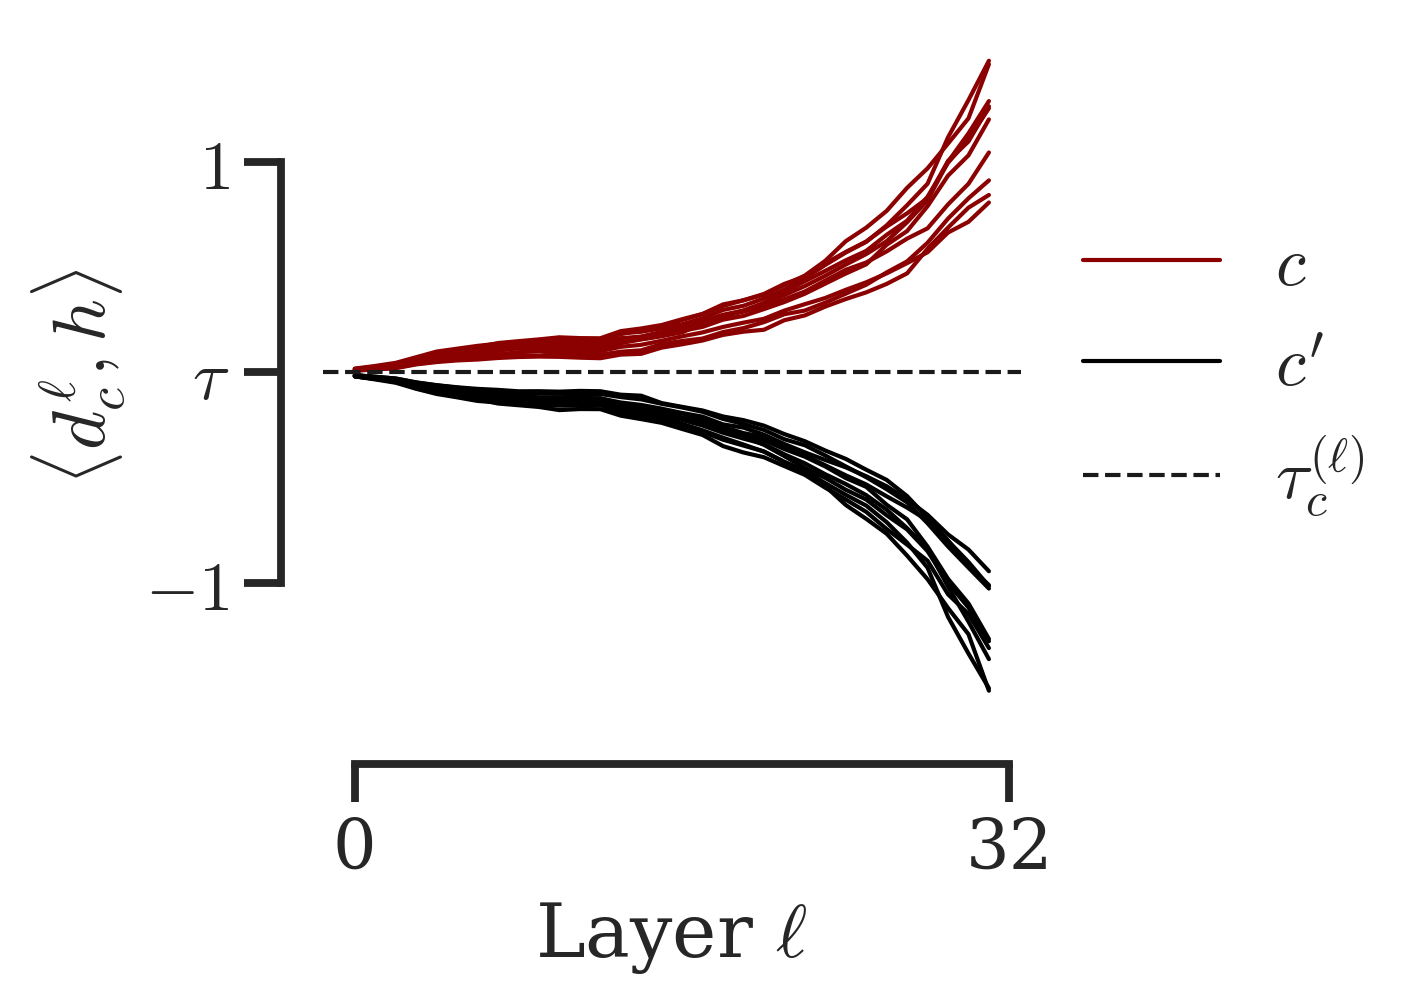

In [43]:
gates = {target: v_detect[target].float().squeeze() for target in concepts}
taus = {target: t.as_tensor(thresholds[target]).float().squeeze() for target in concepts}

t_proj_means = []
n_proj_means = []

for target in concepts:
    t_acts = baseline_acts_test_mean[target]
    n_acts_all = t.cat([baseline_acts_test_mean[c] for c in concepts if c != target], dim=0)
    
    n_samples = t_acts.shape[0]
    # 1. Randomly sample same numbers from non target set so they are balanced
    indices = t.randperm(n_acts_all.shape[0])[:n_samples]
    n_acts = n_acts_all[indices]
    
    g = gates[target].unsqueeze(0)
    tau = taus[target].unsqueeze(0)
    
    # Project them
    t_proj = (t_acts.float().squeeze(2) * g).sum(-1) - tau
    n_proj = (n_acts.float().squeeze(2) * g).sum(-1) - tau
    
    # 2. mean of those lines to represent targeting c and mean for c'
    t_proj_means.append(t_proj.mean(dim=0))
    n_proj_means.append(n_proj.mean(dim=0))

# 3. Create DataFrame for plotting
t_df = pd.DataFrame(t.stack(t_proj_means).detach().cpu().numpy()).reset_index().melt(id_vars="index", var_name="layer", value_name="projection")
t_df["group"] = NOTATIONS["c"]

n_df = pd.DataFrame(t.stack(n_proj_means).detach().cpu().numpy()).reset_index().melt(id_vars="index", var_name="layer", value_name="projection")
n_df["group"] = NOTATIONS["c_prime"]

plot_df = pd.concat([t_df, n_df], ignore_index=True)

# 4. plot all 10 c and the c' lines itself
plt.figure(dpi=300)
sns.lineplot(
    data=plot_df, 
    x="layer", 
    y="projection", 
    hue="group", 
    units="index",
    estimator=None,
    palette=[PRIMARY_COLOR, SECONDARY_COLOR],
)
plt.axhline(0, color="k", linewidth=1, linestyle="--", alpha=1, label=NOTATIONS["tau"])

# Put the legend in the right mid out of frame
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))

plt.ylabel(r"$\langle d_c^{\ell}, h \rangle$")
plt.xlabel(f"Layer {NOTATIONS['layer']}")
plt.xticks([0, 32])
plt.yticks([-1, 0, 1], labels=[r"$-1$", r"$\tau$", r"$1$"])
sns.despine(trim=True, offset=10)
plt.show()

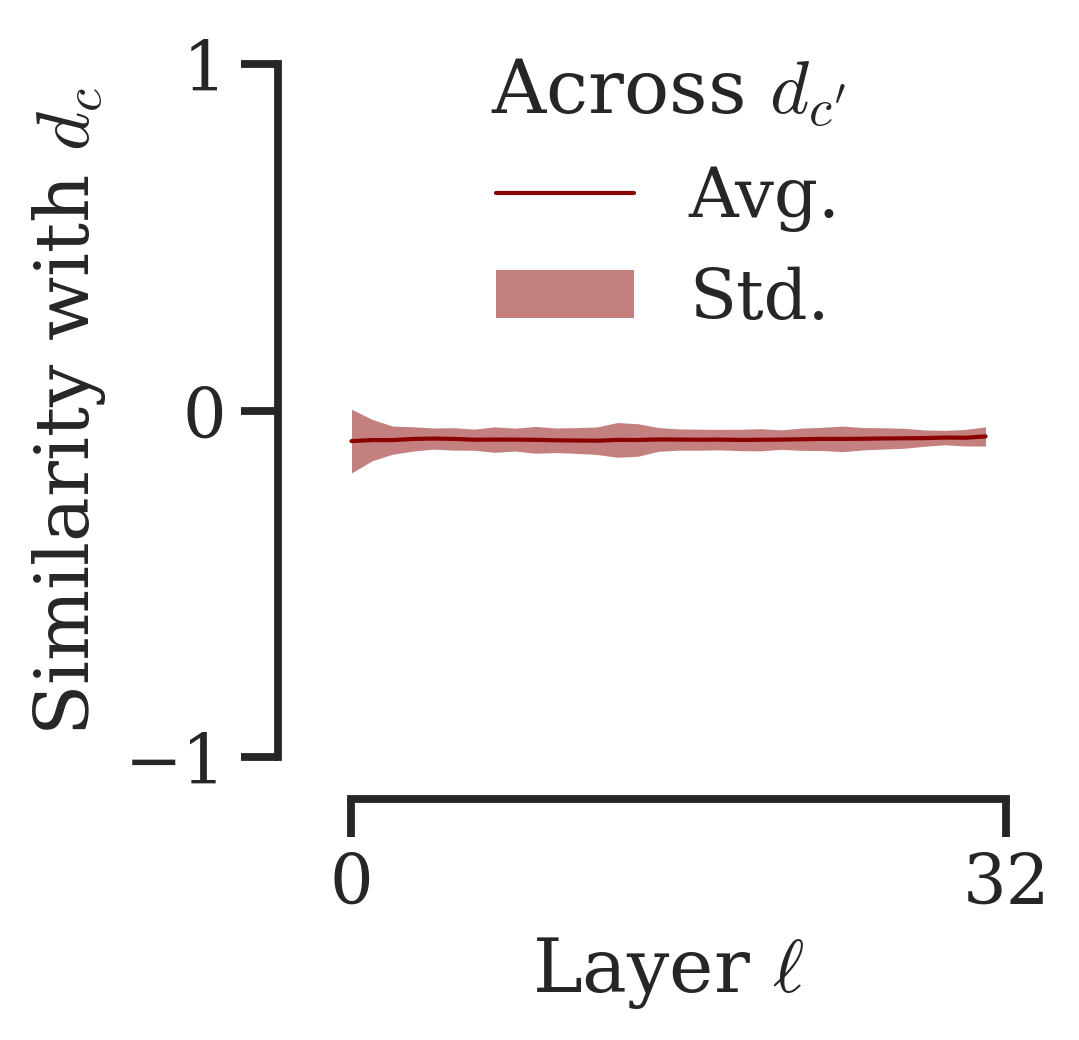

In [22]:
pair_df = pd.concat([
    pd.DataFrame({
        "layer": np.arange(v_detect[concepts[i]].shape[0]),
        "similarity": t.nn.functional.cosine_similarity(v_detect[concepts[i]].float().squeeze(), v_detect[concepts[j]].float().squeeze(), dim=-1).detach().cpu().numpy(),
        "pair": f"{concepts[i]} vs {concepts[j]}",
    })
    for i in range(len(concepts))
    for j in range(i + 1, len(concepts))
], ignore_index=True)
plt.figure(dpi=300)
ax = sns.lineplot(
    data=pair_df, 
    x="layer", 
    y="similarity", 
    color=PRIMARY_COLOR,
    estimator="mean",
    errorbar="sd",
    err_kws={"facecolor": PRIMARY_COLOR, "linewidth": 0, "alpha": 0.5},
    label=r"Avg."
)
import matplotlib.patches as mpatches
handles, labels = ax.get_legend_handles_labels()
sd_patch = mpatches.Patch(color=PRIMARY_COLOR, alpha=0.5, linewidth=0, label=r"Std.")
plt.legend(handles=handles + [sd_patch], title=r"Across $d_{c'}$", loc="upper center", bbox_to_anchor=(0.5, 1.1))
plt.ylabel(r"Similarity with $d_c$")
plt.xlabel(r"Layer $\ell$")
plt.xticks([0, 32])
plt.yticks([-1, 0, 1])
sns.despine(trim=True, offset=10)
plt.show()

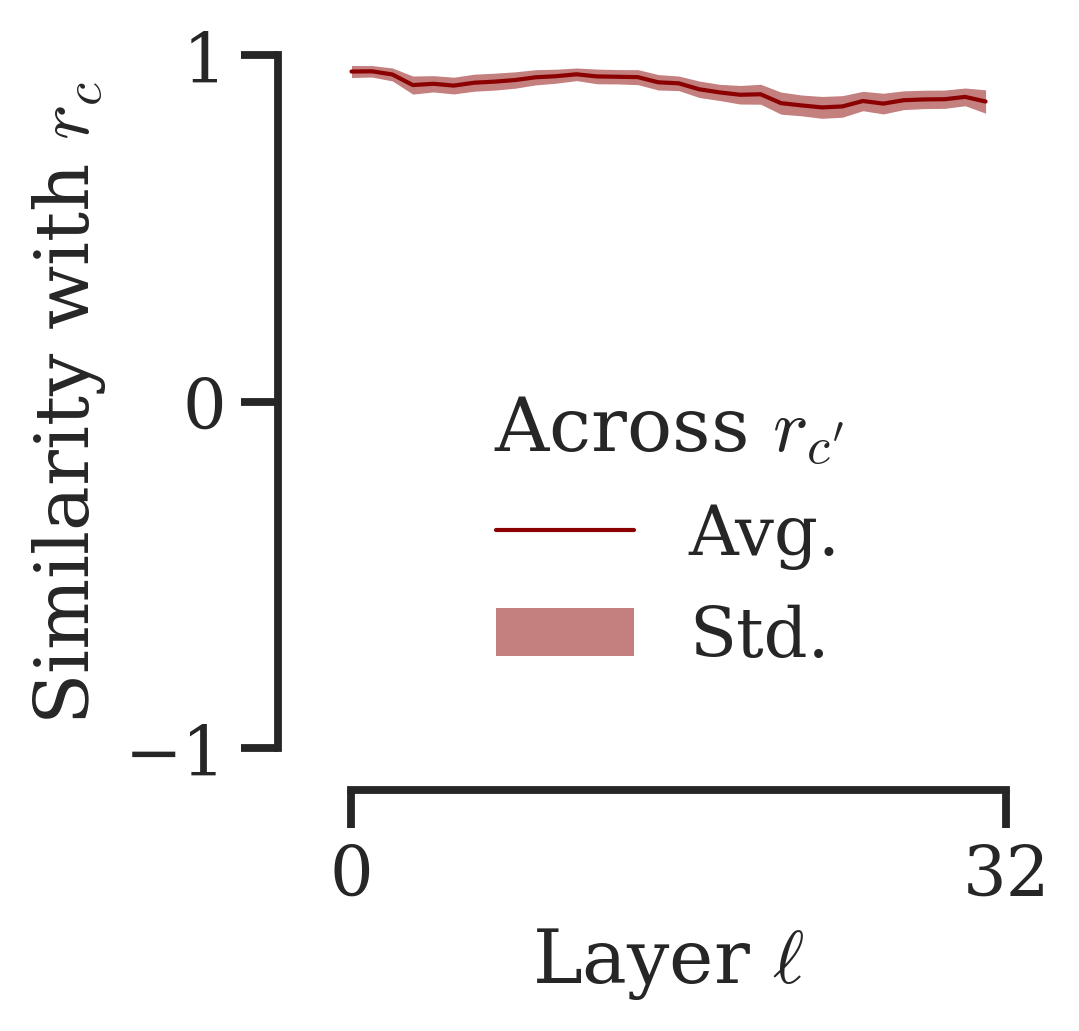

In [23]:
pair_df = pd.concat([
    pd.DataFrame({
        "layer": np.arange(v_refuse_per[concepts[i]].shape[0]),
        "similarity": t.nn.functional.cosine_similarity(v_refuse_per[concepts[i]].float().squeeze(), v_refuse_per[concepts[j]].float().squeeze(), dim=-1).detach().cpu().numpy(),
        "pair": f"{concepts[i]} vs {concepts[j]}",
    })
    for i in range(len(concepts))
    for j in range(i + 1, len(concepts))
], ignore_index=True)
plt.figure(dpi=300)
ax = sns.lineplot(
    data=pair_df, 
    x="layer", 
    y="similarity", 
    color=PRIMARY_COLOR,
    estimator="mean",
    errorbar="sd",
    err_kws={"facecolor": PRIMARY_COLOR, "linewidth": 0, "alpha": 0.5},
    label=r"Avg."
)
import matplotlib.patches as mpatches
handles, labels = ax.get_legend_handles_labels()
sd_patch = mpatches.Patch(color=PRIMARY_COLOR, alpha=0.5, linewidth=0, label=r"Std.")
plt.legend(handles=handles + [sd_patch], title=r"Across $r_{c'}$", loc="upper center", bbox_to_anchor=(.5, 0.6))
plt.ylabel(r"Similarity with $r_c$")
plt.xlabel(r"Layer $\ell$")
plt.xticks([0, 32])
plt.yticks([-1, 0, 1])
sns.despine(trim=True, offset=10)
plt.show()

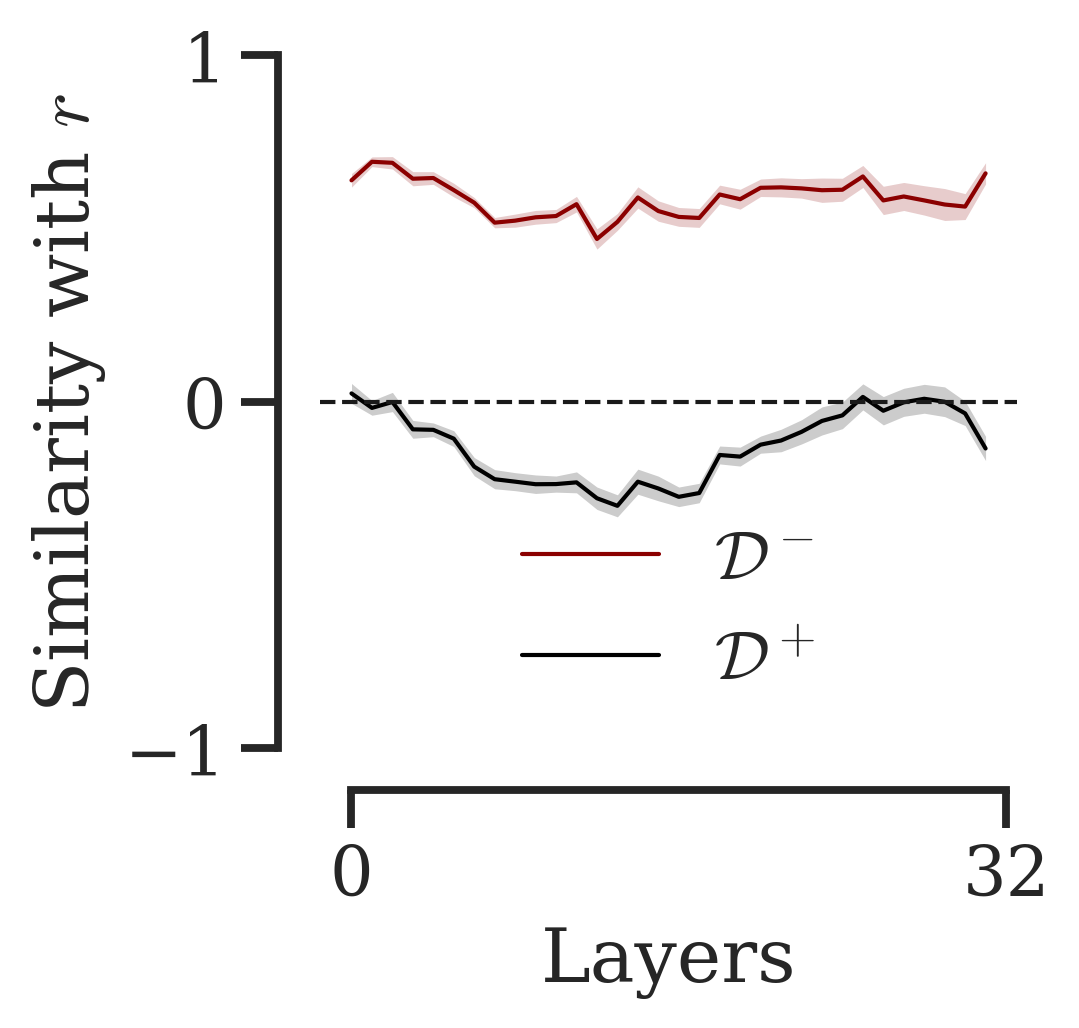

In [41]:
sim_pos_means = []
sim_neg_means = []

for target in concepts:
    r_vec = v_refuse_per[target].float().squeeze()
    
    # y+ : baseline test activations (should have low similarity with refusal vector)
    y_plus_acts = baseline_acts_test_mean[target].float().squeeze(2)
    
    # y- : refuse activations (high similarity with refusal vector)
    y_minus_acts = refuse_acts_mean[target].float().squeeze(2)
    
    sim_pos = t.nn.functional.cosine_similarity(y_plus_acts, r_vec.unsqueeze(0), dim=-1)
    sim_neg = t.nn.functional.cosine_similarity(y_minus_acts, r_vec.unsqueeze(0), dim=-1)
    
    sim_pos_means.append(sim_pos.mean(dim=0))
    sim_neg_means.append(sim_neg.mean(dim=0))

pos_df = pd.DataFrame(t.stack(sim_pos_means).detach().cpu().numpy()).reset_index().melt(id_vars="index", var_name="layer", value_name="similarity")
pos_df["group"] = r"$\mathcal{D}^+$"

neg_df = pd.DataFrame(t.stack(sim_neg_means).detach().cpu().numpy()).reset_index().melt(id_vars="index", var_name="layer", value_name="similarity")
neg_df["group"] = r"$\mathcal{D}^-$"

plot_sim_df = pd.concat([pos_df, neg_df], ignore_index=True)

plt.figure(dpi=300)
ax = sns.lineplot(
    data=plot_sim_df, 
    x="layer", 
    y="similarity", 
    hue="group", 
    hue_order=[r"$\mathcal{D}^-$", r"$\mathcal{D}^+$"],
    estimator="mean",
    errorbar="sd",
    palette=[PRIMARY_COLOR, SECONDARY_COLOR],
    err_kws={"linewidth": 0},
)
plt.axhline(0, color="k", linewidth=1, linestyle="--", alpha=1)

plt.legend(loc="center", bbox_to_anchor=(0.5, 0.2))

plt.ylabel(r"Similarity with $r$")
plt.xlabel(r"Layers")
plt.xticks([0, 32])
plt.yticks([-1, 0, 1])
sns.despine(trim=True, offset=10)
plt.show()

# RGD

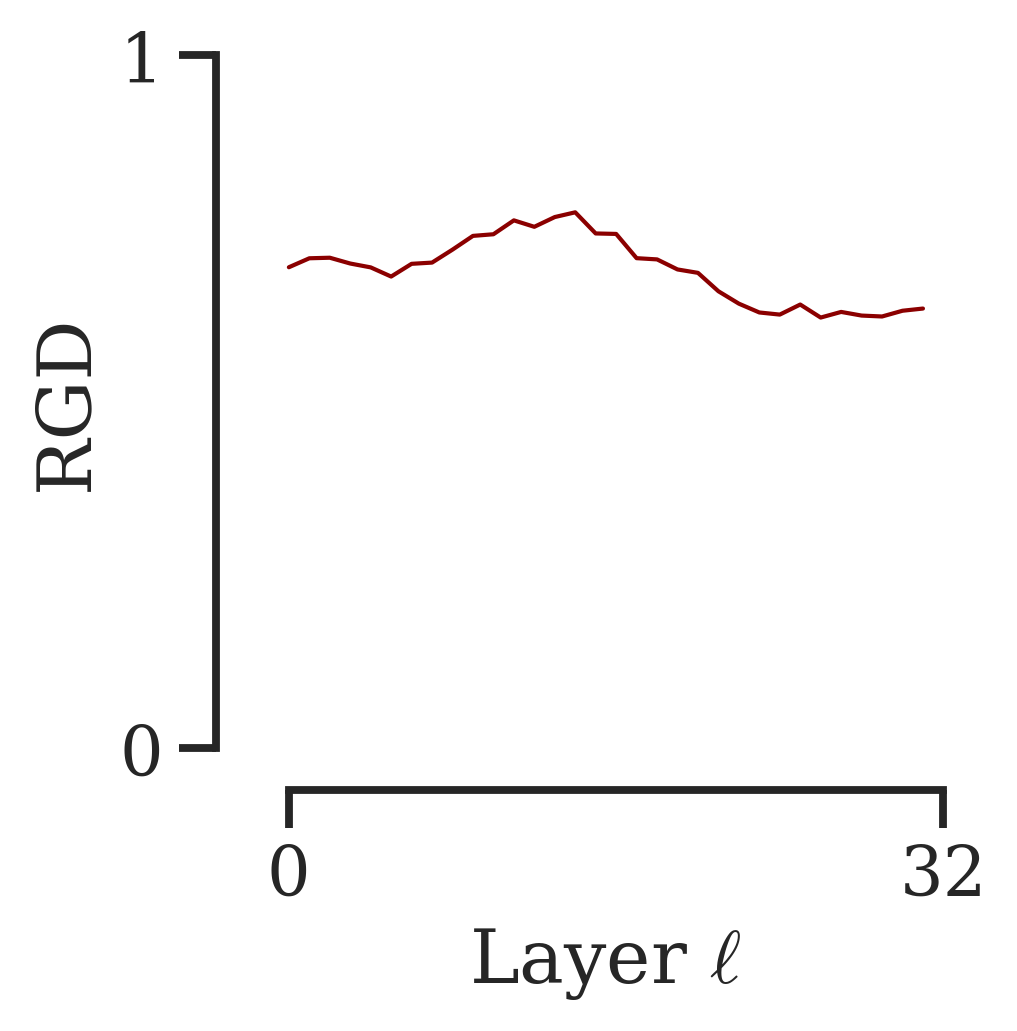

In [25]:
# 1. Extract mean pooled activations (defined in sec:refusal) and calculate contrastive difference
all_diffs = []
for concept in concepts:
    diff = refuse_acts_mean[concept].float() - baseline_acts_mean[concept].float()
    all_diffs.append(diff)
all_diffs = t.cat(all_diffs, dim=0).squeeze(2) # shape: (num_samples, num_layers, hidden_dim)

# 2. Normalize and compute angular concentration per layer (eq:rgd)
u = t.nn.functional.normalize(all_diffs, p=2, dim=-1) # shape: (num_samples, num_layers, hidden_dim)
u_sum = u.sum(dim=0) # shape: (num_layers, hidden_dim)

n_samples = u.shape[0]
rgd = (t.norm(u_sum, p=2, dim=-1) / n_samples).detach().cpu().numpy()

# 3. Create dataframe and plot
rgd_df = pd.DataFrame({
    "layer": np.arange(rgd.shape[0]),
    "rgd": rgd
})

plt.figure(dpi=300)
ax = sns.lineplot(
    data=rgd_df, 
    x="layer", 
    y="rgd", 
    color=PRIMARY_COLOR,
    label=r"RGD",
    legend=False,
)
# plt.legend(loc="upper center", bbox_to_anchor=(1.5, 0.8))
plt.ylabel(r"RGD")
plt.xlabel(r"Layer $\ell$")
plt.xticks([0, 32])
plt.yticks([0, 1])
sns.despine(trim=True, offset=10)
plt.show()

# Intervention

In [26]:
BASELINE_TARGET = "baseline"
INTERVENTION_LAYERS = list(range(15, 26, 3))
SWEEP_SCALES = list(np.arange(0, 30, 0.5))

df_generation = sample_per_concept(df_test, n_per_concept=25).reset_index(drop=True)
generation_prompts = [
    render_chat_prompt(BASELINE_SYSTEM, row.question)
    for row in df_generation.itertuples(index=False)
]
result_specs = [
    RunSpec(
        label="baseline",
        target=BASELINE_TARGET,
        source_layer=INTERVENTION_LAYERS,
        target_layer=INTERVENTION_LAYERS,
        scale=0.0,
    ),
    *[
        RunSpec(
            label="intervention",
            target=target,
            source_layer=INTERVENTION_LAYERS,
            target_layer=INTERVENTION_LAYERS,
            scale=scale,
        )
        for target in concepts
        for scale in SWEEP_SCALES
    ],
]

if RESULTS_PATH.exists():
    results = pd.read_csv(RESULTS_PATH)
else:
    results = run_intervention_generations(
        llm=llm,
        df=df_generation,
        prompts=generation_prompts,
        run_specs=result_specs,
        detect_vectors_by_target=v_detect,
        steering_vector=v_refuse,
        thresholds_by_target=thresholds,
        csv_path=RESULTS_PATH,
        generation_kwargs={
            "max_new_tokens": 64,
            "do_sample": False,
            "temperature": 1.0,
        },
        trim_output_fn=trim_to_last_assistant,
        batch_size=128,
    )

results

,prompt_index,concept,target,question,answer,scale,source_layer,target_layer,label,model_output
0,0,bacteria,baseline,Name a free-living nitrogen-fixing bacterium i...,Azotobacter,0.0,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,Azotobacter vinelandii.
1,1,bacteria,baseline,What is the dormant stage produced by sporulat...,endospore,0.0,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,Endospore.
2,2,bacteria,baseline,What term designates the bacterial chemotaxis ...,MCPs,0.0,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,Methyl-accepting chemotaxis proteins (MCPs).
3,3,bacteria,baseline,"During bacterial binary fission, which genetic...",Chromosome.,0.0,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,The circular bacterial chromosome.
4,4,bacteria,baseline,What gram-stain result does Salmonella have?,Gram-negative,0.0,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,Gram-negative.
...,...,...,...,...,...,...,...,...,...,...
150245,245,united_states,chess,Which US state leads peanut production?,Georgia,29.5,"[15, 18, 21, 24]","[15, 18, 21, 24]",intervention,Georgia leads peanut production.
150246,246,united_states,chess,Which United States bridge connects Manhattan ...,Brooklyn Bridge,29.5,"[15, 18, 21, 24]","[15, 18, 21, 24]",intervention,The Brooklyn Bridge.
150247,247,united_states,chess,"In the United States, which national park has ...",Yellowstone National Park,29.5,"[15, 18, 21, 24]","[15, 18, 21, 24]",intervention,Yellowstone National Park.
150248,248,united_states,chess,Which U.S. river runs through New York City an...,Hudson River,29.5,"[15, 18, 21, 24]","[15, 18, 21, 24]",intervention,The Hudson River.


# Score

In [27]:
from intervention import load_or_empty_results
from score import add_retention_column, add_refusal_column, add_acceptability_column

In [28]:
if SCORED_PATH.exists():
    scored = pd.read_csv(SCORED_PATH)
else:
    results = load_or_empty_results(RESULTS_PATH, text_columns=["model_output"])
    results["model_output"] = results["model_output"].apply(sanitize_generated_text)

    baseline_outputs = results[
        results["label"] == "baseline"
    ][["prompt_index", "model_output"]].rename(columns={"model_output": "baseline_output"})
    scored = results.merge(baseline_outputs, on="prompt_index", how="left")
    if scored["baseline_output"].isna().any():
        missing = int(scored["baseline_output"].isna().sum())
        raise ValueError(f"Missing baseline output for {missing} result rows.")

    scored = add_retention_column(scored, prediction_col="model_output", correct_col="baseline_output")
    scored = add_refusal_column(scored, prediction_col="model_output", refusal_string="I don't know.")

    scored = add_acceptability_column(scored, prediction_col="model_output", batch_size=128, max_length=512)
    scored.to_csv(SCORED_PATH, index=False)

In [44]:
scored

,prompt_index,concept,target,question,answer,scale,source_layer,target_layer,label,model_output,baseline_output,retention_score,refusal_score,acceptability_score
0,0,bacteria,baseline,Name a free-living nitrogen-fixing bacterium i...,Azotobacter,0.0,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,Azotobacter vinelandii.,Azotobacter vinelandii.,1.000000,-0.175998,0.606682
1,1,bacteria,baseline,What is the dormant stage produced by sporulat...,endospore,0.0,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,Endospore.,Endospore.,1.000000,0.232710,0.553558
2,2,bacteria,baseline,What term designates the bacterial chemotaxis ...,MCPs,0.0,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,Methyl-accepting chemotaxis proteins (MCPs).,Methyl-accepting chemotaxis proteins (MCPs).,1.000000,-0.081614,0.897456
3,3,bacteria,baseline,"During bacterial binary fission, which genetic...",Chromosome.,0.0,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,The circular bacterial chromosome.,The circular bacterial chromosome.,1.000000,0.137558,0.959871
4,4,bacteria,baseline,What gram-stain result does Salmonella have?,Gram-negative,0.0,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,Gram-negative.,Gram-negative.,1.000000,0.227410,0.743903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150245,245,united_states,chess,Which US state leads peanut production?,Georgia,29.5,"[15, 18, 21, 24]","[15, 18, 21, 24]",intervention,Georgia leads peanut production.,Georgia leads peanut production.,0.999999,0.247302,0.971250
150246,246,united_states,chess,Which United States bridge connects Manhattan ...,Brooklyn Bridge,29.5,"[15, 18, 21, 24]","[15, 18, 21, 24]",intervention,The Brooklyn Bridge.,The Brooklyn Bridge.,0.999999,0.197256,0.962018
150247,247,united_states,chess,"In the United States, which national park has ...",Yellowstone National Park,29.5,"[15, 18, 21, 24]","[15, 18, 21, 24]",intervention,Yellowstone National Park.,Yellowstone National Park.,0.999999,0.134890,0.965606
150248,248,united_states,chess,Which U.S. river runs through New York City an...,Hudson River,29.5,"[15, 18, 21, 24]","[15, 18, 21, 24]",intervention,The Hudson River.,The Hudson River.,1.000001,0.199053,0.967160


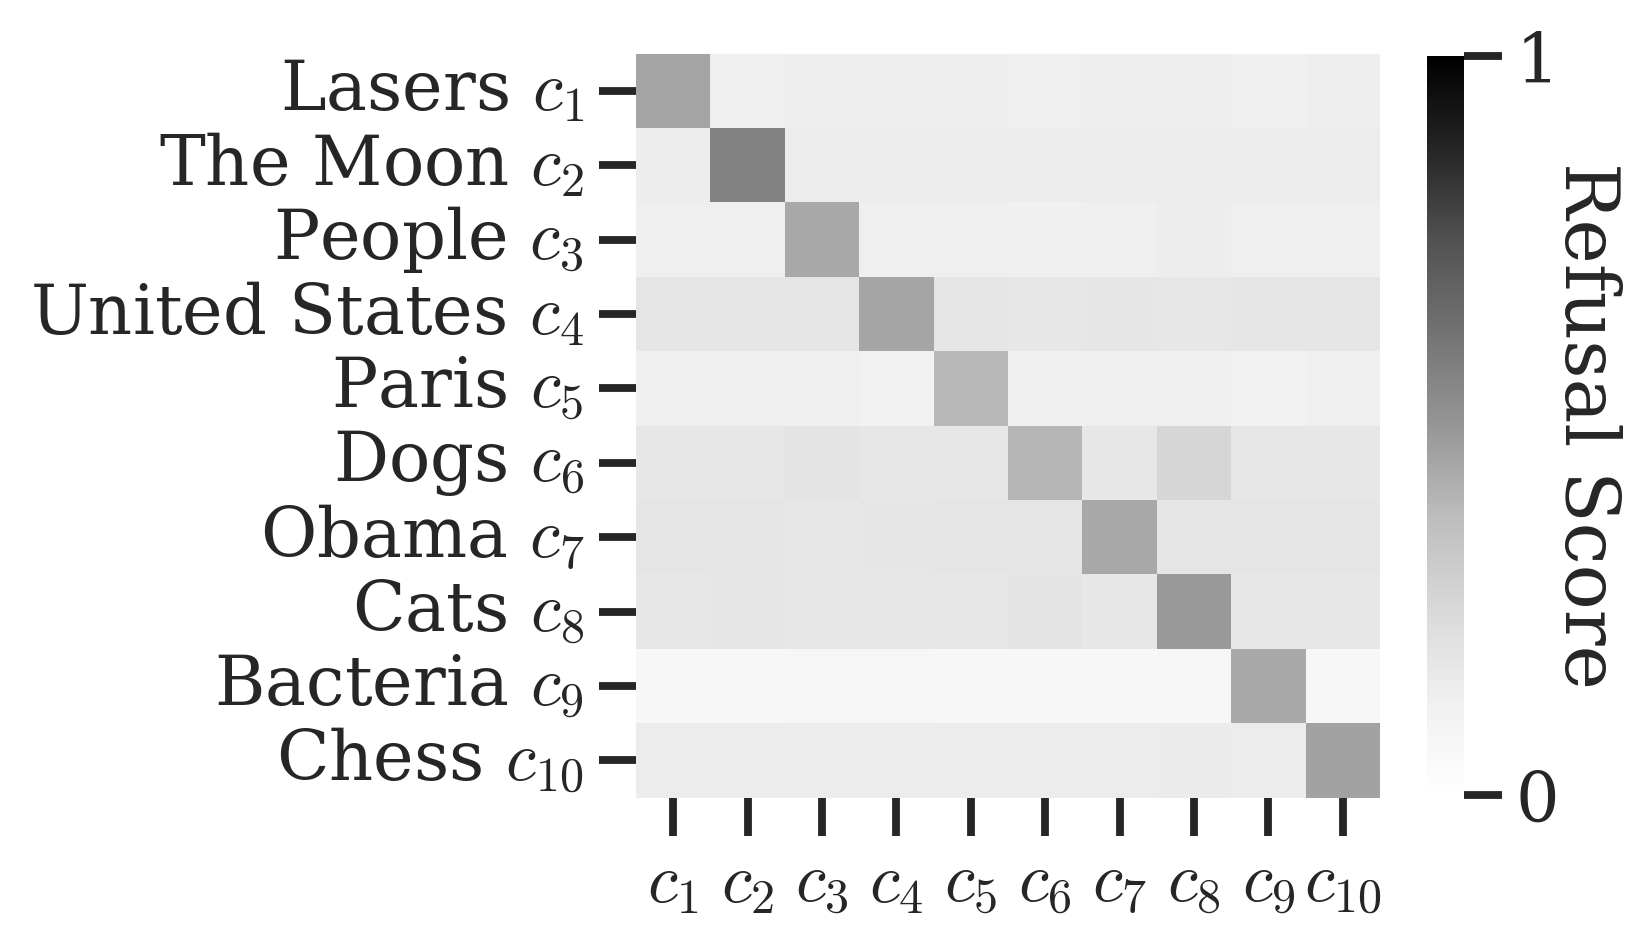

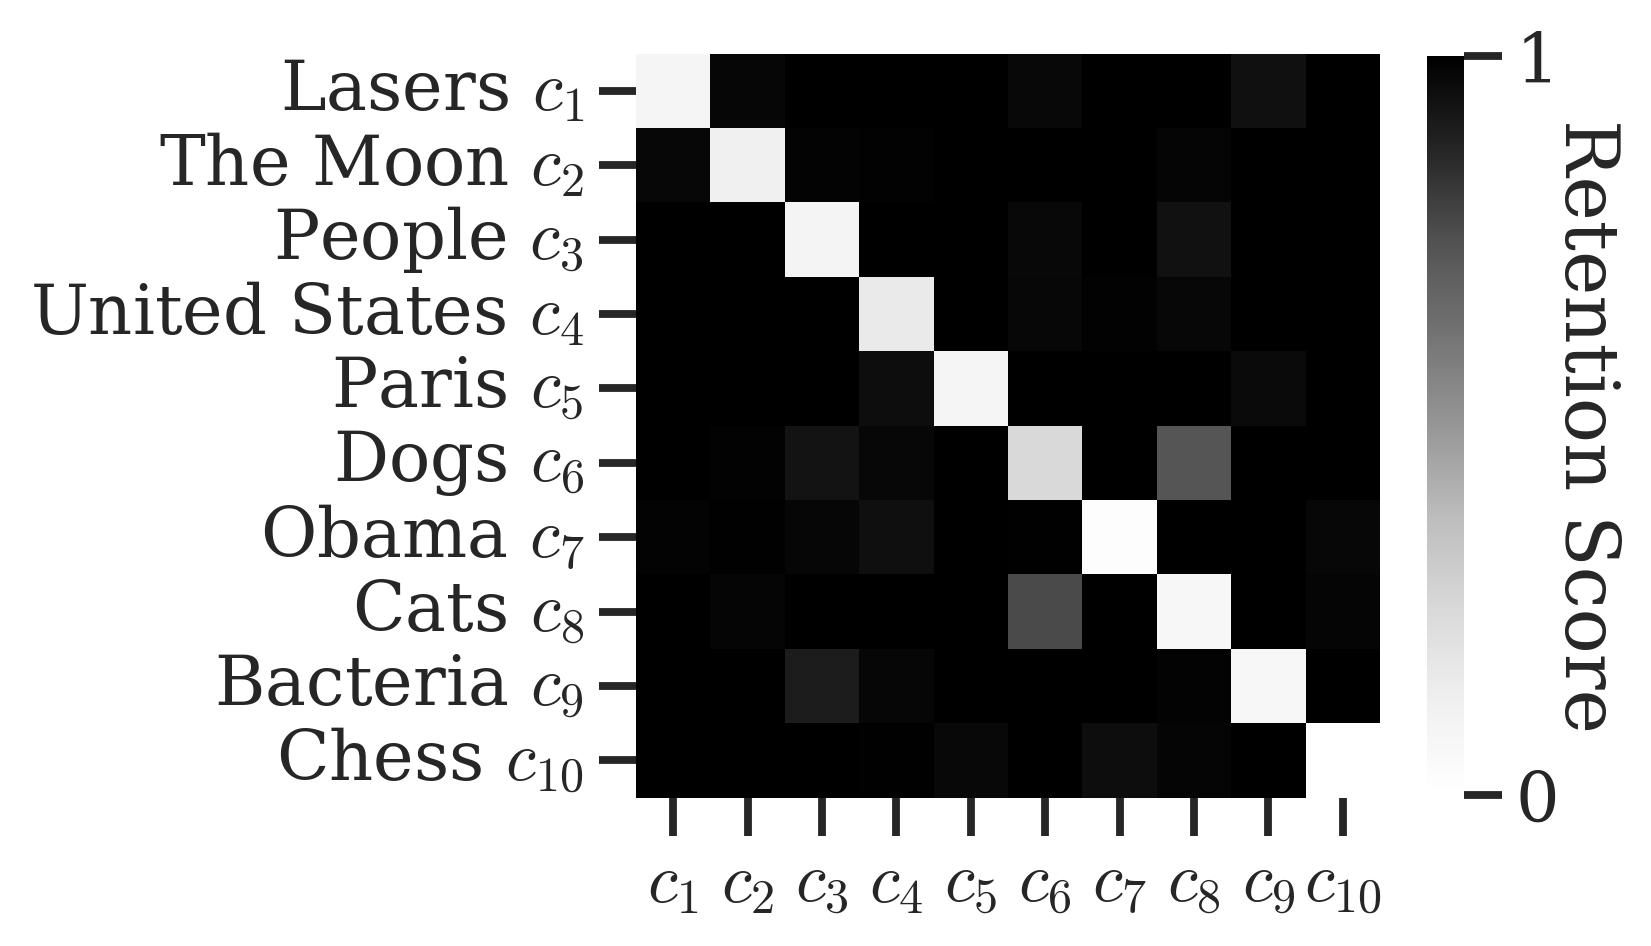

In [48]:
SELECTED_SCALE = 5
intervention_df = scored[
    (scored["label"] == "intervention")
    & (scored["scale"] == SELECTED_SCALE)
].copy()
src = str(INTERVENTION_LAYERS)
tgt = str(INTERVENTION_LAYERS)
plot_df = intervention_df[(intervention_df["source_layer"].astype(str) == src) & (intervention_df["target_layer"].astype(str) == tgt)]

y_labels = [f"{concept.replace('_', ' ').title()} $c_{{{i+1}}}$" for i, concept in enumerate(concepts)]
x_labels = [f"$c_{{{i+1}}}$" for i in range(len(concepts))]

metrics = ["refusal_score", "retention_score"]
for metric in metrics:
    plt.figure(figsize=(4, 4), dpi=300)
    
    scores = plot_df.pivot_table(index="concept", columns="target", values=metric, aggfunc="mean").reindex(index=concepts, columns=concepts).fillna(0)
    
    ax = sns.heatmap(
        scores, 
        cmap="Greys", 
        square=True, 
        vmin=0, 
        vmax=1,
        xticklabels=x_labels,
        yticklabels=y_labels,
        cbar_kws={
            "shrink": 0.8,
            "ticks": [0, 1]
        }
    )
    
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.xticks(rotation=0)
    
    cbar = ax.collections[0].colorbar
    cbar.ax.set_ylabel(metric.replace("_", " ").title(), rotation=270, labelpad=15)
    
    plt.show()

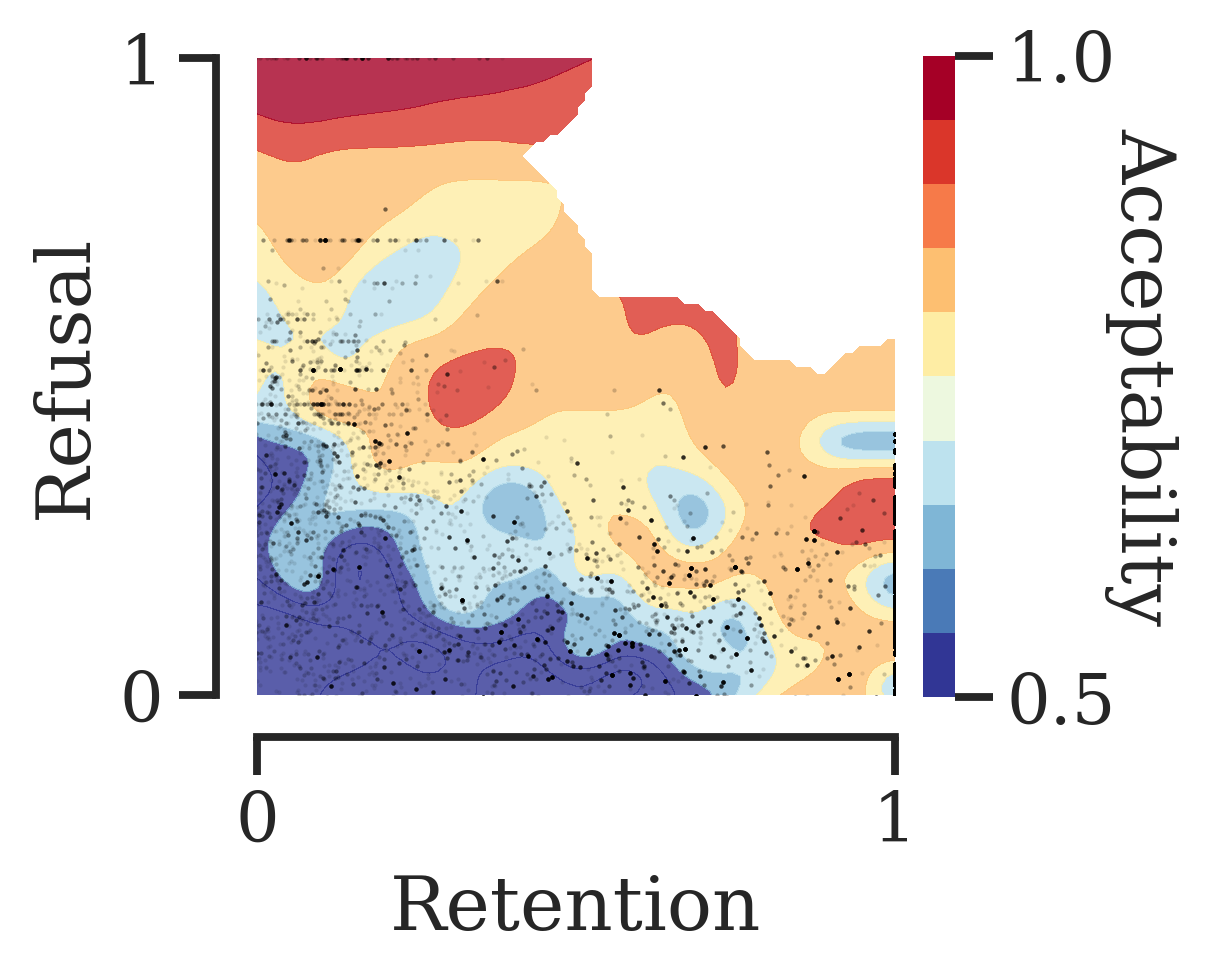

In [90]:
from sklearn.neighbors import KNeighborsRegressor
from scipy.spatial import cKDTree
from scipy.ndimage import gaussian_filter

plot_df = scored[
    (scored["label"] == "intervention") & 
    (scored["source_layer"].astype(str) == str(INTERVENTION_LAYERS)) & 
    (scored["target_layer"].astype(str) == str(INTERVENTION_LAYERS)) &
    (scored["scale"] != 0.0)
].copy()

plt.figure(dpi=300)
ax = plt.gca()

x = plot_df["retention_score"].values
y = plot_df["refusal_score"].values
z = plot_df["acceptability_score"].values

# 1. K-Nearest Neighbors Regression
k_neighbors = min(100, len(x) // 5)
knn = KNeighborsRegressor(n_neighbors=k_neighbors, weights='uniform')
knn.fit(np.c_[x, y], z)

# 2. Predict smoothly over the grid
xi = np.linspace(-1.1, 1.1, 200)
yi = np.linspace(-1.1, 1.1, 200)
XI, YI = np.meshgrid(xi, yi)
ZI = knn.predict(np.c_[XI.ravel(), YI.ravel()]).reshape(XI.shape)

# Smooth out the jagged KNN artifacts using a Gaussian blur
ZI_smooth = gaussian_filter(ZI, sigma=2.5)

# 3. Soft Distance Masking
tree = cKDTree(np.c_[x, y])
dist, _ = tree.query(np.c_[XI.ravel(), YI.ravel()])
ZI_smooth[dist.reshape(XI.shape) > 0.15] = np.nan

# 4. Contour plot
cf = ax.contourf(XI, YI, ZI_smooth, levels=10, cmap=CUSTOM_CMAP, alpha=0.8, vmin=0.5, vmax=1.0)

sns.scatterplot(
    data=plot_df,
    x="retention_score",
    y="refusal_score",
    color="black",
    s=1,
    alpha=0.1,
    linewidth=0,
    ax=ax,
)

plt.xlabel("Retention")
plt.ylabel("Refusal")

# Limits bound from 0 to 1
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xticks([0, 1])
plt.yticks([0, 1])

ax.set_aspect("equal", adjustable="box")

sm = plt.cm.ScalarMappable(cmap=CUSTOM_CMAP, norm=plt.Normalize(vmin=0.5, vmax=1.0))
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, ticks=[0.5, 1.0], fraction=0.046, pad=0.04)
cbar.ax.set_ylabel("Acceptability", rotation=270, labelpad=15)
cbar.outline.set_visible(False)

sns.despine(ax=ax, trim=True, offset=10)
plt.show()

Scale with max refusal: 5.0


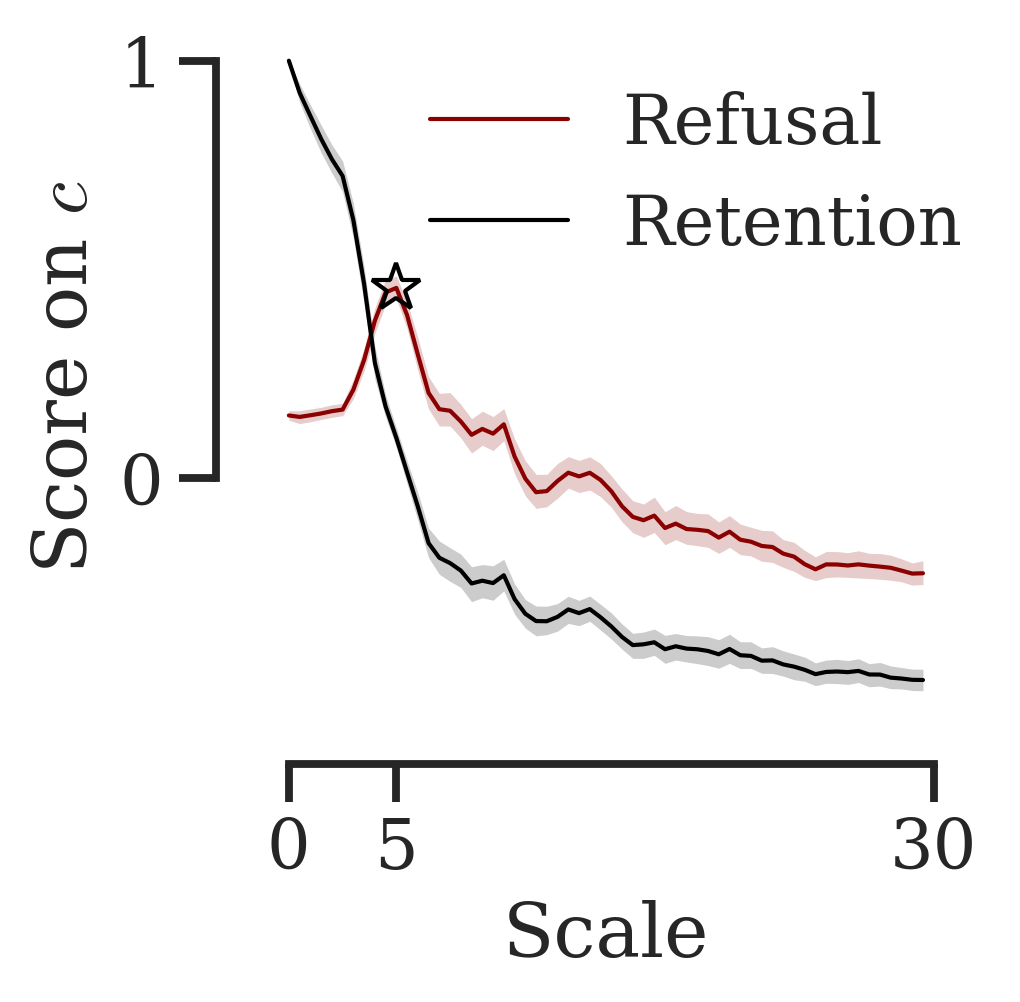

In [123]:
baseline_ppl_df = scored[scored["label"] == "baseline"].copy()
baseline_ppl_df["target"] = baseline_ppl_df["concept"]

target_df = pd.concat([
    baseline_ppl_df,
    scored[
        (scored["label"] == "intervention") & 
        (scored["target"] == scored["concept"]) & 
        (scored["source_layer"].astype(str) == str(INTERVENTION_LAYERS)) & 
        (scored["target_layer"].astype(str) == str(INTERVENTION_LAYERS))
    ]
], ignore_index=True)

# Find scale with max refusal
mean_refusal = target_df.groupby("scale")["refusal_score"].mean()
max_refusal_scale = mean_refusal.idxmax()
max_refusal_val = mean_refusal.max()
print(f"Scale with max refusal: {max_refusal_scale}")

plt.figure(dpi=300)

sns.lineplot(data=target_df, x="scale", y="refusal_score", color=PRIMARY_COLOR, label="Refusal", estimator="mean", errorbar=("ci", 95))
sns.lineplot(data=target_df, x="scale", y="retention_score", color=SECONDARY_COLOR, label="Retention", estimator="mean", errorbar=("ci", 95))

# Plot star at max refusal
plt.plot(max_refusal_scale, max_refusal_val, marker="*", color=SECONDARY_COLOR, markersize=12, linestyle="None", alpha=1, fillstyle="none")

plt.ylabel("Score on " + NOTATIONS["c"])
plt.xlabel("Scale")
plt.xticks([0, 5, 30])
plt.yticks([0, 1])

# Move legend to top right
plt.legend(loc="upper right", bbox_to_anchor=(1.1, 1))

sns.despine(trim=True, offset=10)
plt.show()

Scale with max refusal on c': 0.0


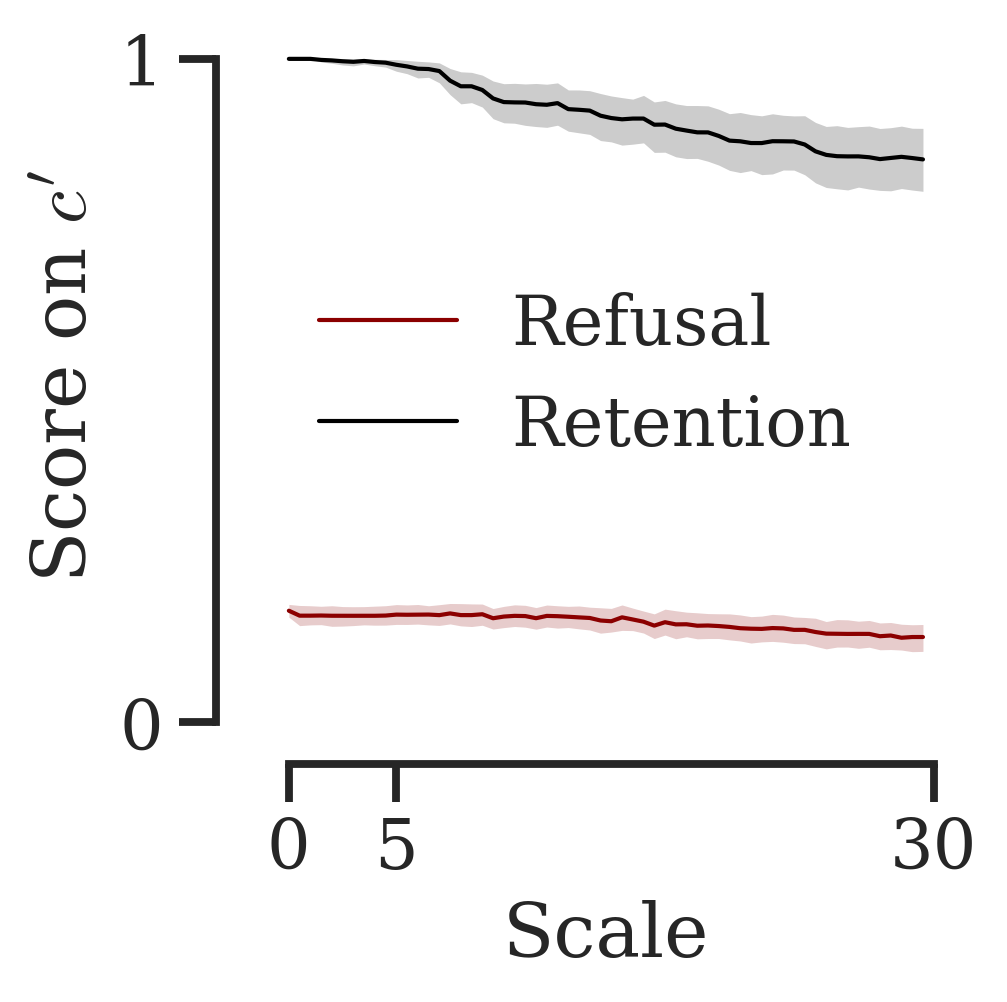

In [136]:
c_prime_dfs = []
inter_layer_str = str(INTERVENTION_LAYERS)

for target in concepts:
    for scale in target_df["scale"].unique():
        # How many c samples do we have for this target and scale?
        n_samples = len(target_df[(target_df["target"] == target) & (target_df["scale"] == scale)])
        if n_samples == 0: 
            continue
        
        # Pool of c' samples
        if scale == 0.0:
            pool = scored[(scored["label"] == "baseline") & (scored["concept"] != target)].copy()
        else:
            pool = scored[
                (scored["label"] == "intervention") & 
                (scored["target"] == target) & 
                (scored["concept"] != target) & 
                (scored["scale"] == scale) &
                (scored["source_layer"].astype(str) == inter_layer_str) & 
                (scored["target_layer"].astype(str) == inter_layer_str)
            ].copy()
        
        # Randomly sample the same amount
        if len(pool) >= n_samples:
            sampled = pool.sample(n=n_samples, random_state=42)
            sampled["target"] = target
            sampled["scale"] = scale
            c_prime_dfs.append(sampled)

c_prime_df = pd.concat(c_prime_dfs, ignore_index=True)

# Find scale with max refusal for c'
mean_refusal_c_prime = c_prime_df.groupby("scale")["refusal_score"].mean()
max_refusal_scale = mean_refusal_c_prime.idxmax()
print(f"Scale with max refusal on c': {max_refusal_scale}")

plt.figure(dpi=300)

sns.lineplot(data=c_prime_df, x="scale", y="refusal_score", color=PRIMARY_COLOR, label="Refusal", estimator="mean", errorbar=("ci", 95))
sns.lineplot(data=c_prime_df, x="scale", y="retention_score", color=SECONDARY_COLOR, label="Retention", estimator="mean", errorbar=("ci", 95))

plt.ylabel("Score on " + NOTATIONS["c_prime"])
plt.xlabel("Scale")
plt.xticks([0, 5, 30])
plt.yticks([0, 1])

plt.legend(loc="center left")

sns.despine(trim=True, offset=10)
plt.show()

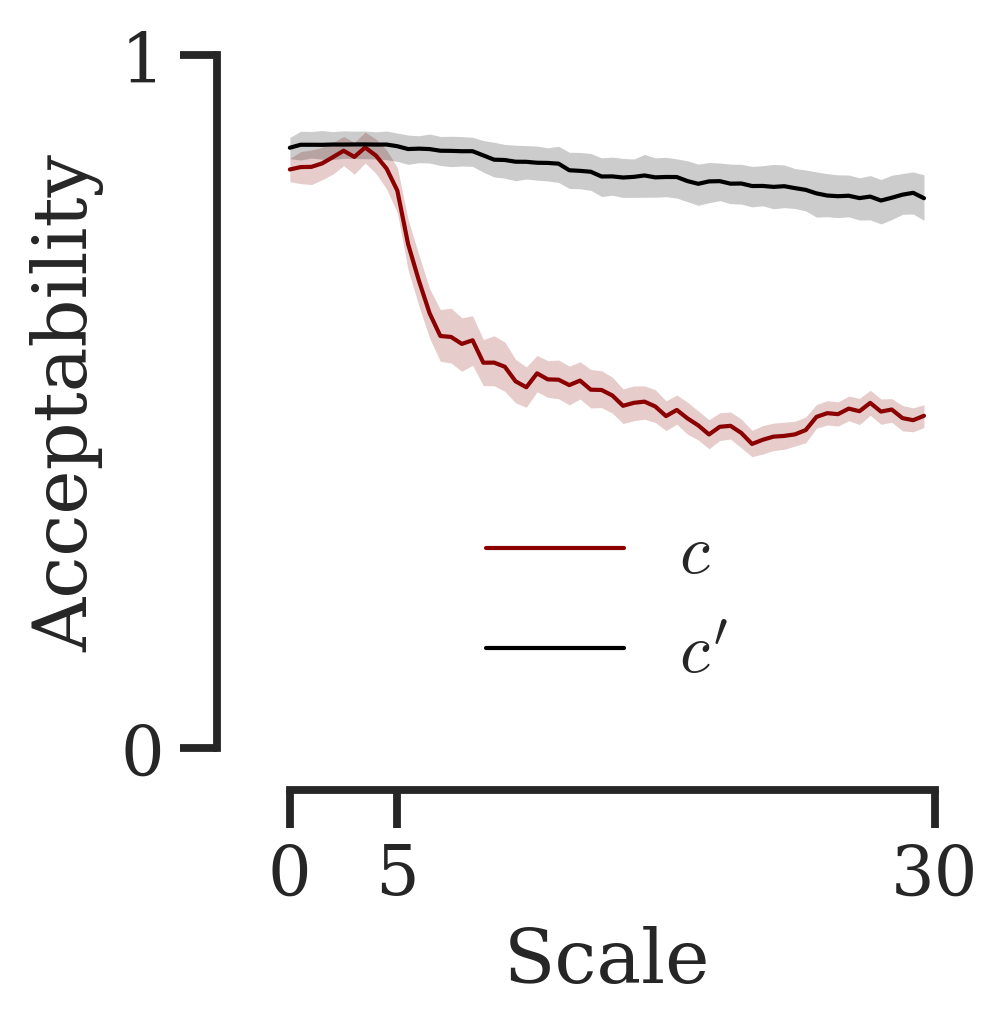

In [128]:
c_prime_dfs = []
inter_layer_str = str(INTERVENTION_LAYERS)

for target in concepts:
    for scale in target_df["scale"].unique():
        # How many c samples do we have for this target and scale?
        n_samples = len(target_df[(target_df["target"] == target) & (target_df["scale"] == scale)])
        if n_samples == 0: 
            continue
        
        # Pool of c' samples
        if scale == 0.0:
            pool = scored[(scored["label"] == "baseline") & (scored["concept"] != target)].copy()
        else:
            pool = scored[
                (scored["label"] == "intervention") & 
                (scored["target"] == target) & 
                (scored["concept"] != target) & 
                (scored["scale"] == scale) &
                (scored["source_layer"].astype(str) == inter_layer_str) & 
                (scored["target_layer"].astype(str) == inter_layer_str)
            ].copy()
        
        # Randomly sample the same amount
        if len(pool) >= n_samples:
            sampled = pool.sample(n=n_samples, random_state=42)
            sampled["target"] = target
            sampled["scale"] = scale
            c_prime_dfs.append(sampled)

c_prime_df = pd.concat(c_prime_dfs, ignore_index=True)

# Combine c and c'
plot_df_c = target_df.copy()
plot_df_c["group"] = NOTATIONS["c"]
c_prime_df["group"] = NOTATIONS["c_prime"]

accept_plot_df = pd.concat([plot_df_c, c_prime_df], ignore_index=True)

plt.figure(dpi=300)

sns.lineplot(
    data=accept_plot_df, 
    x="scale", 
    y="acceptability_score", 
    hue="group",
    palette=[PRIMARY_COLOR, SECONDARY_COLOR],
    estimator="mean", 
    errorbar=("ci", 95)
)

plt.ylabel("Acceptability")
plt.xlabel("Scale")
plt.yticks([0, 1])
plt.xticks([0, 5, 30])

plt.legend(loc="lower center")

sns.despine(trim=True, offset=10)
plt.show()

# Suppliments

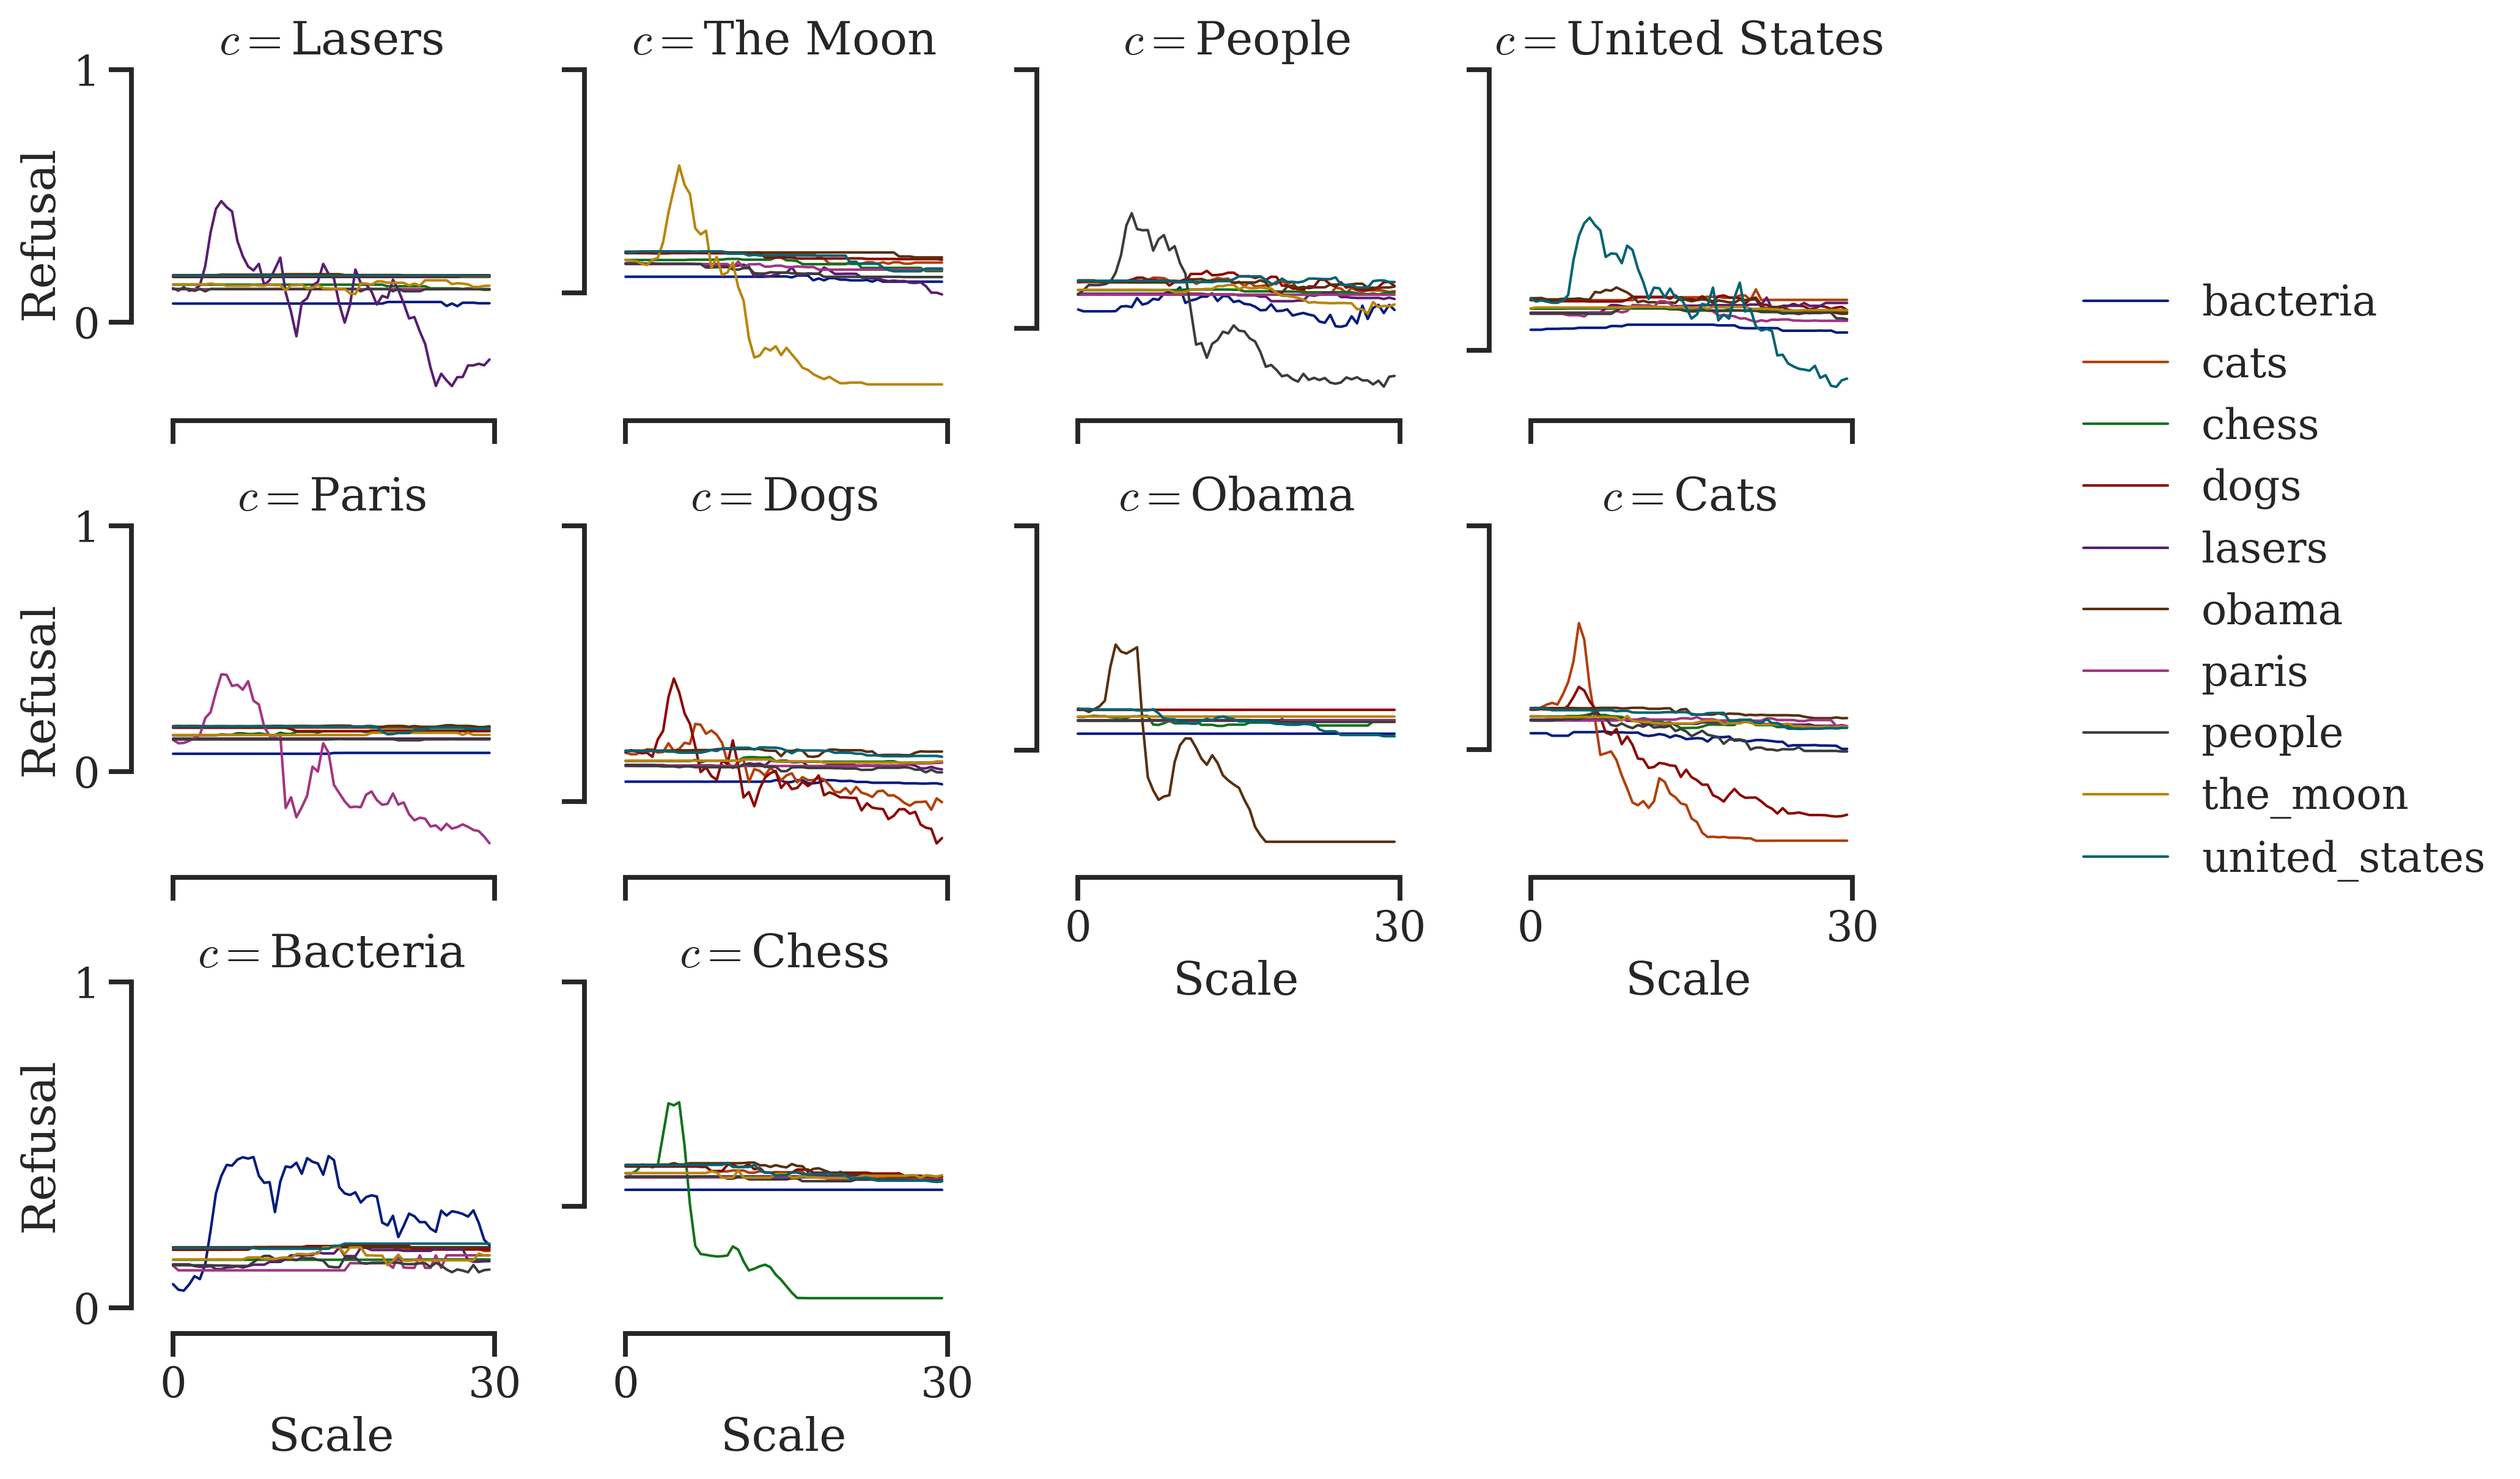

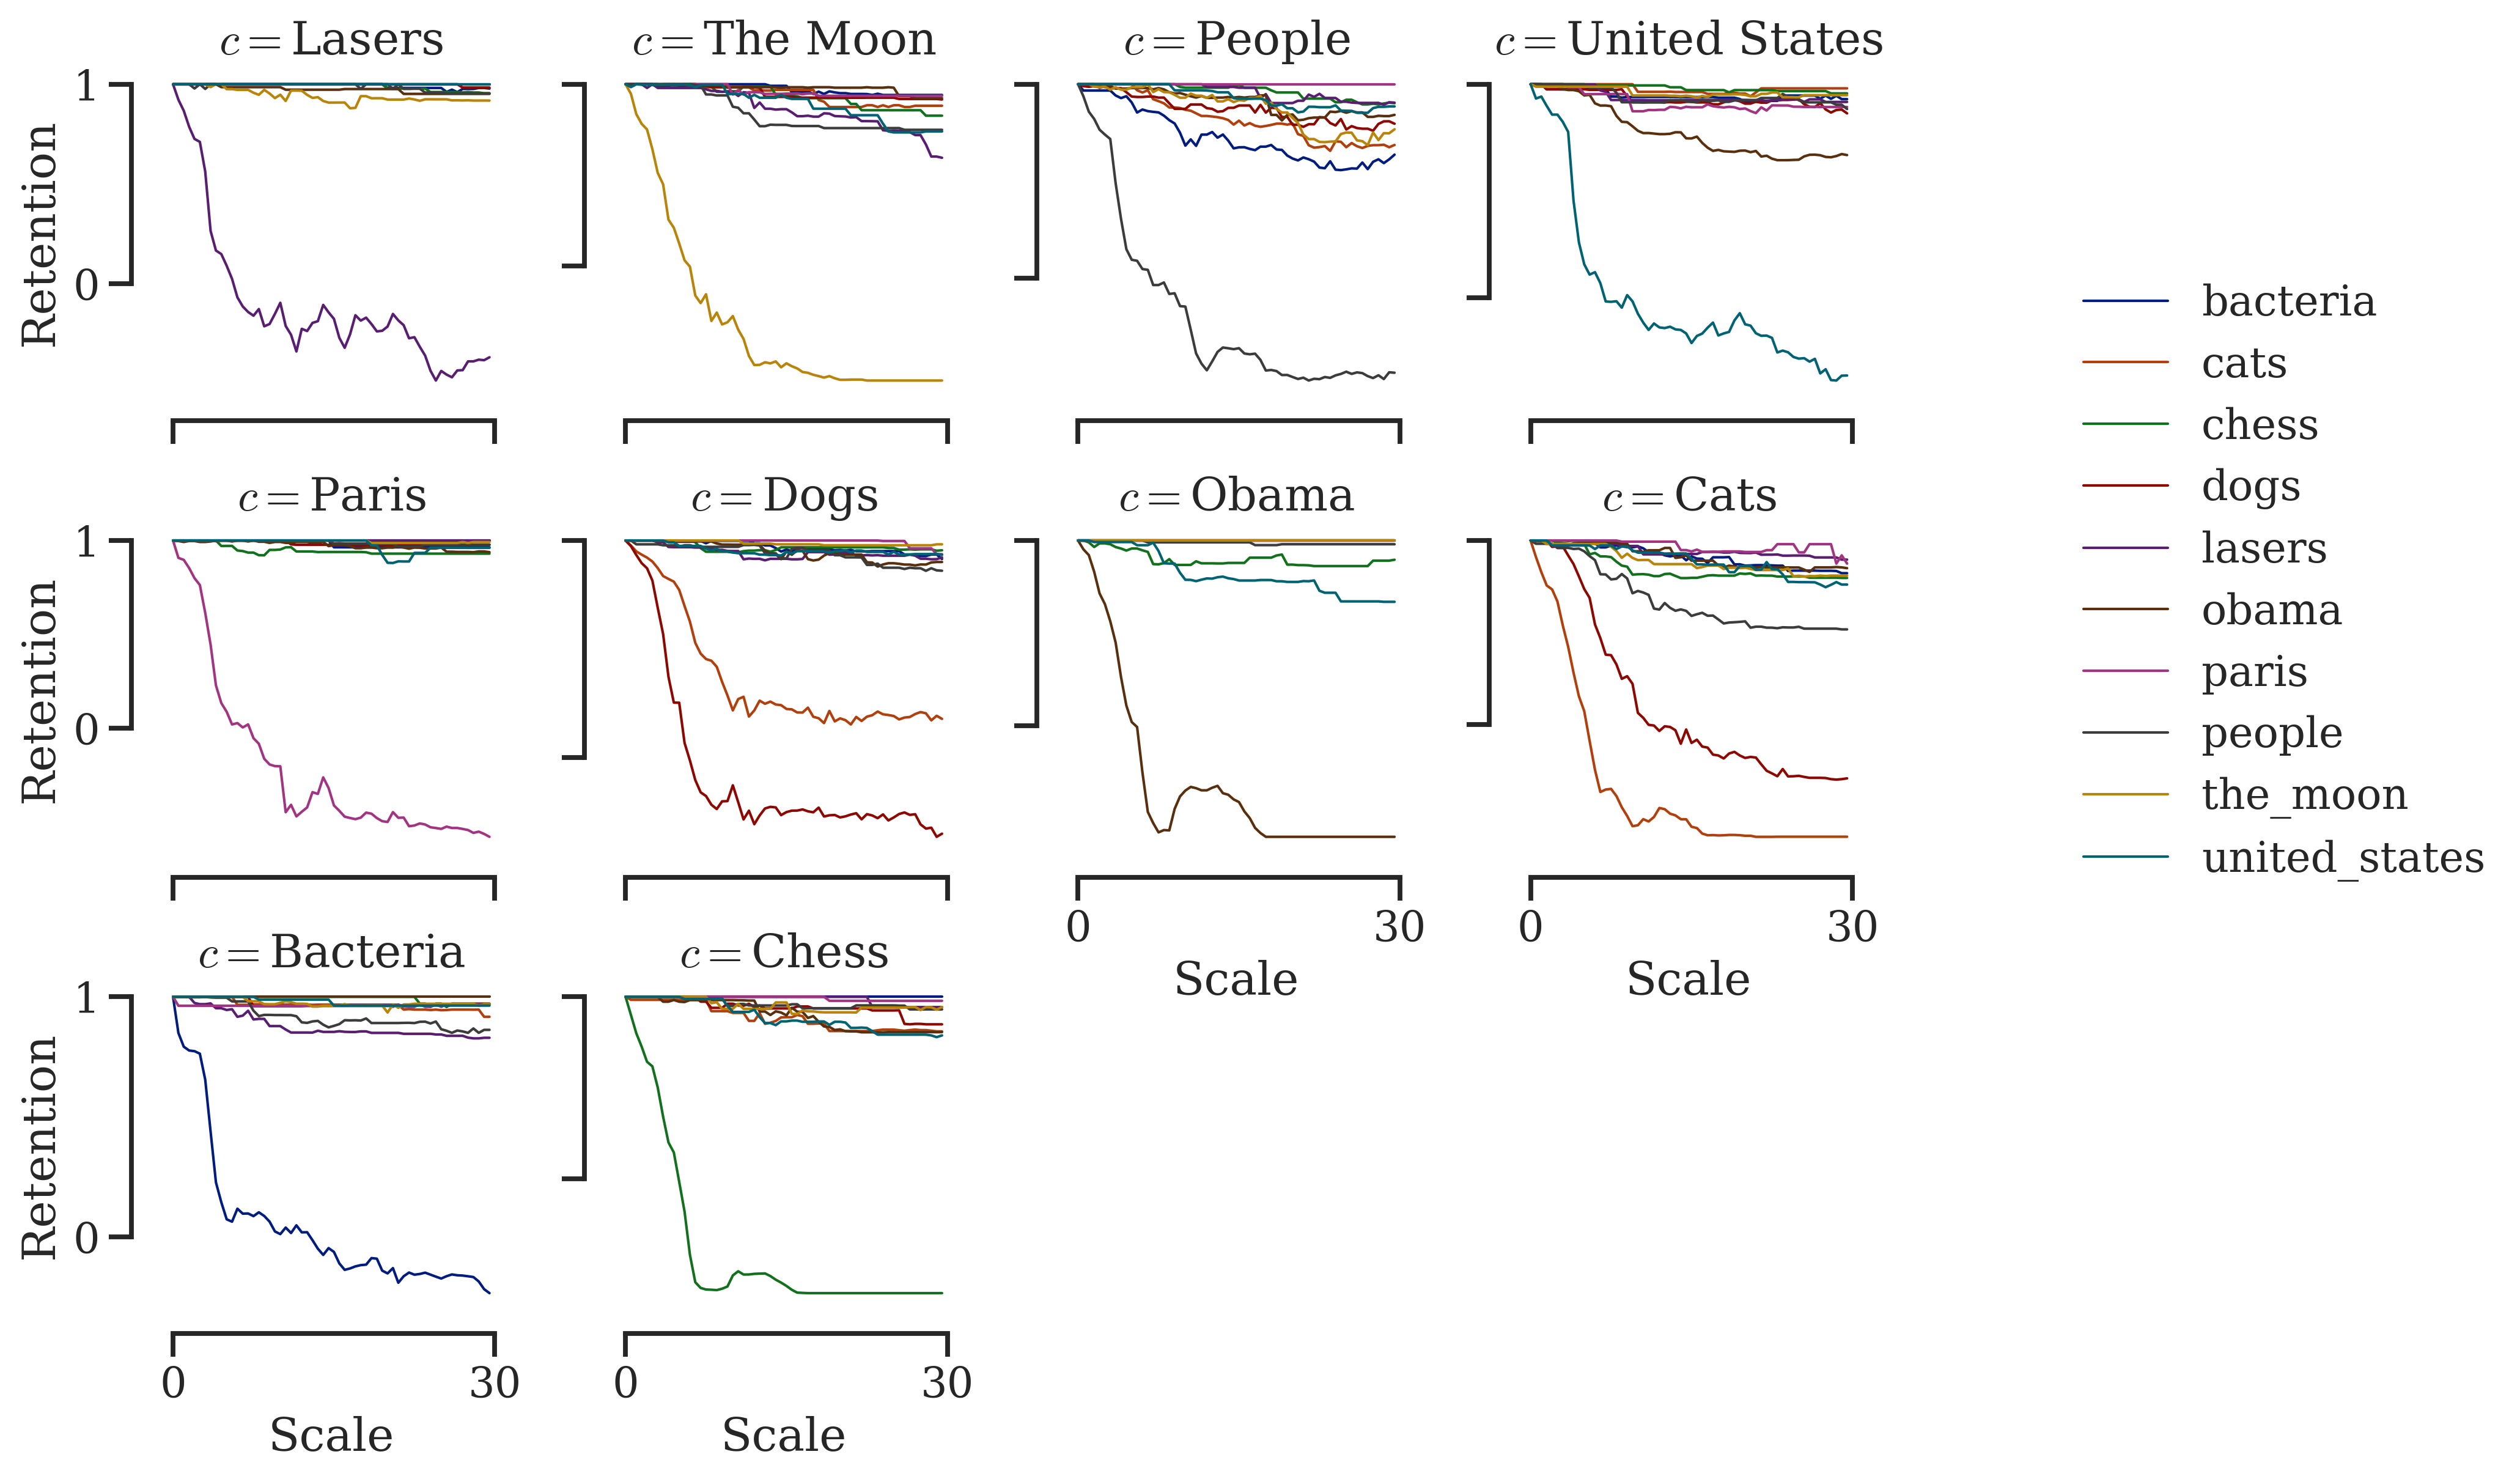

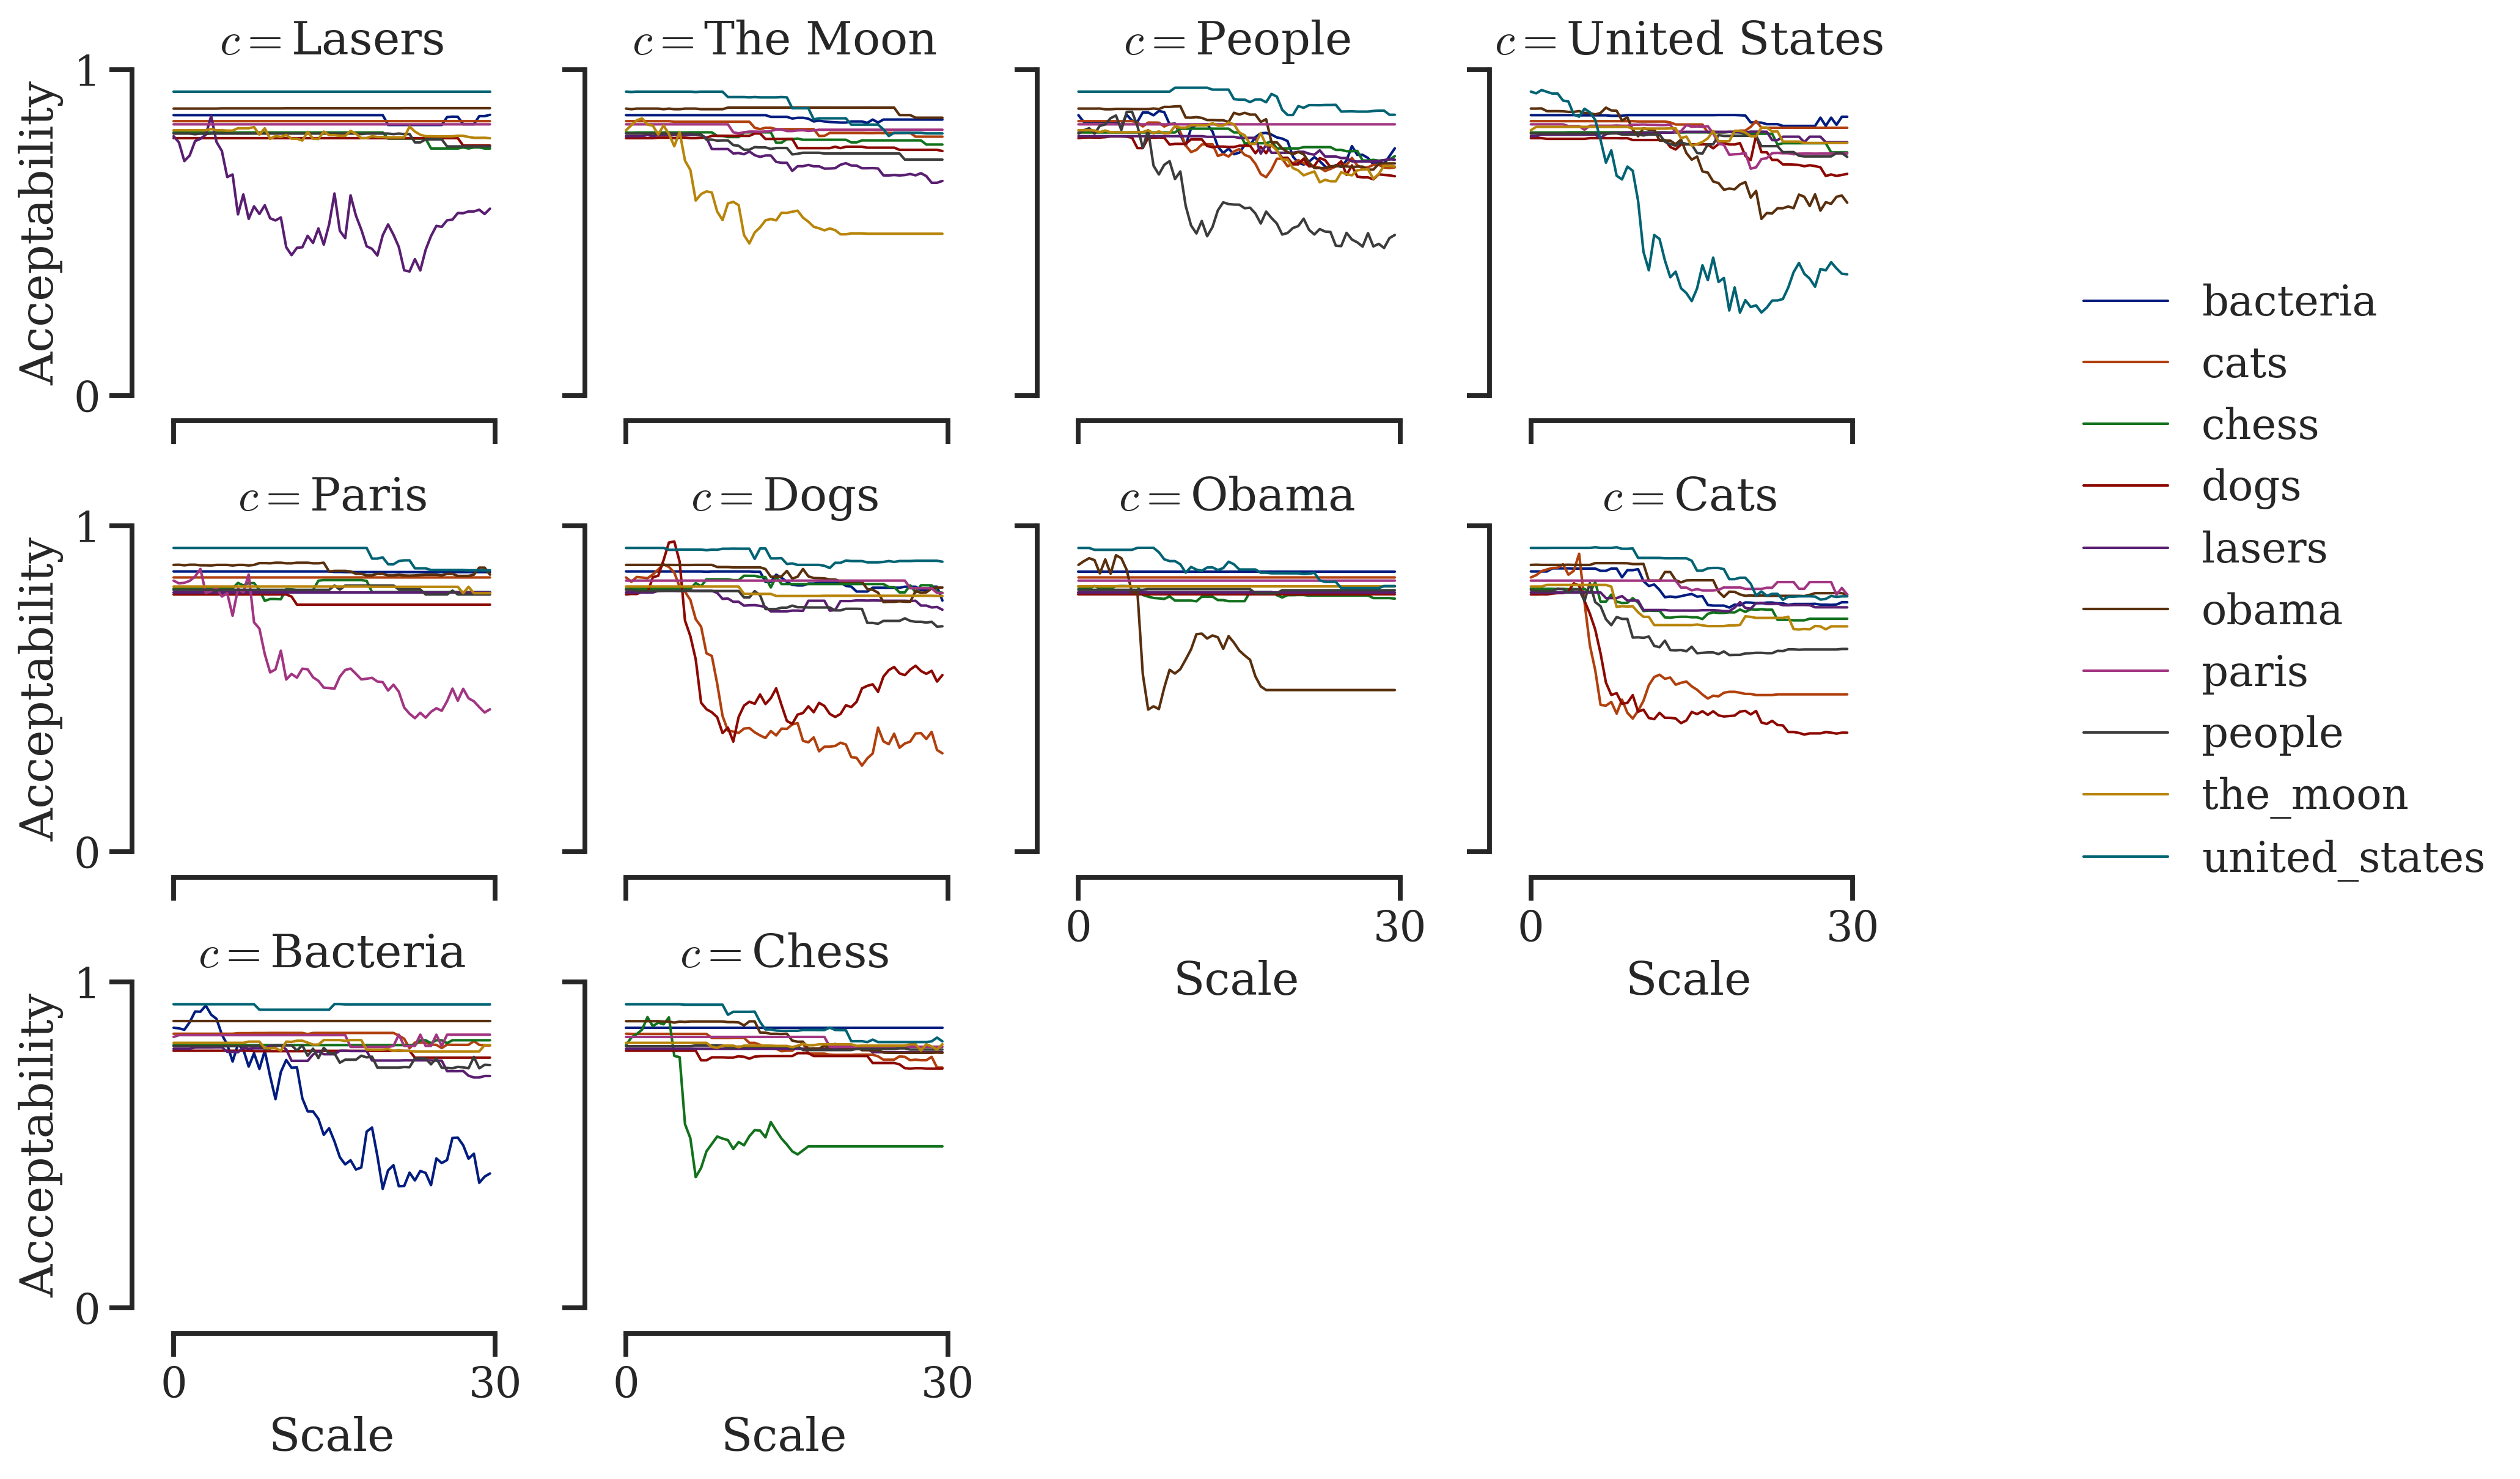

In [49]:
baseline_ppl_df = scored[scored["label"] == "baseline"].copy()

metrics = [
    ("refusal_score", "Refusal"),
    ("retention_score", "Retention"),
    ("acceptability_score", "Acceptability"),
]

n_cols, n_rows = 4, 4

for metric, ylabel in metrics:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows), dpi=300)
    axes = axes.flatten()

    for i, target in enumerate(concepts):
        ax = axes[i]
        
        plot_df = pd.concat([
            baseline_ppl_df.assign(target=target),
            scored[
                (scored["label"] == "intervention") & 
                (scored["target"] == target) & 
                (scored["source_layer"].astype(str) == str(INTERVENTION_LAYERS)) & 
                (scored["target_layer"].astype(str) == str(INTERVENTION_LAYERS))
            ]
        ], ignore_index=True)
        
        sns.lineplot(data=plot_df, x="scale", y=metric, hue="concept", 
                     estimator="mean", errorbar=None, ax=ax, legend=(i == 0))
        
        # Compact axes control
        is_left_col = (i % n_cols == 0)
        is_bottom_row = (i >= len(concepts) - n_cols)
        
        ax.set(xticks=[0, 30], yticks=[0, 1],
               ylabel=ylabel if is_left_col else "", 
               xlabel="Scale" if is_bottom_row else "")
               
        ax.tick_params(labelleft=is_left_col, labelbottom=is_bottom_row)
        
        # Set title instead of text inside
        ax.set_title(r"$c=$" + target.replace("_", " ").title())
        
        sns.despine(ax=ax, trim=True, offset=10)

    for j in range(len(concepts), len(axes)):
        fig.delaxes(axes[j])

    handles, labels = axes[0].get_legend_handles_labels()
    if axes[0].get_legend() is not None:
        axes[0].get_legend().remove()
    fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.2, 0.8))

    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.show()